# Comparativa oferta–demanda — Sprint 4
## StaySpain vs. Encuesta de Ocupación Hotelera (EOH)

Notebook unificado para análisis y presentación.

Integra:

- la comparativa completa de oferta y demanda;
- los gráficos y tablas de validación;
- la Opportunity Matrix de cuadrantes;
- la matriz de evidencia por destino;
- la matriz de decisiones y acciones;
- la temporalidad de 2025 y el patrón medio 2023–2025;
- la composición por **pernoctaciones** y por **viajeros**;
- todos los bookmarks e interpretaciones relevantes de las dos versiones originales.

Solo se han eliminado bloques que repetían exactamente el mismo gráfico o la misma explicación.


<a id="indice-graficos-matrices"></a>
## 🔖 Navegación rápida — gráficos, matrices e interpretaciones

### Preparación y tablas
1. [Registro de notebooks](#registro-notebooks)
2. [Tabla maestra oferta–demanda](#tabla-maestra)
3. [Interpretación de la tabla maestra](#interpretacion-tabla-maestra)
4. [Validaciones](#validaciones)

### Gráficos
1. [Composición de pernoctaciones por residencia](#grafico-composicion)
2. [Composición de viajeros por residencia](#grafico-composicion-viajeros)
3. [Volumen de pernoctaciones](#grafico-pernoctaciones)
4. [Estancia media vs. noches mínimas](#grafico-estancia)
5. [Heatmap de estacionalidad 2025](#grafico-heatmap)
6. [Heatmap medio de estacionalidad 2023–2025](#grafico-heatmap-2023-2025)
7. [Participación de oferta vs. demanda](#grafico-oferta-demanda)
8. [Opportunity Matrix de cuadrantes](#grafico-opportunity-matrix)
9. [Matriz de evidencia por destino](#matriz-evidencia)
10. [Matriz de decisión y acción](#matriz-acciones)
11. [Brecha demanda − oferta](#grafico-brecha)
12. [Principal CCAA de procedencia](#grafico-procedencia)
13. [Crecimiento de pernoctaciones 2023–2025](#grafico-crecimiento)

### Matrices y tablas finales
- [Opportunity Matrix por destino](#tabla-opportunity-matrix)
- [Tabla corta para diapositiva](#tabla-resumen-presentacion)
- [Salidas dentro del notebook](#salidas-inline)

### Interpretaciones

1. [Tabla maestra oferta–demanda](#interpretacion-tabla-maestra)
2. [Composición de pernoctaciones por residencia](#interpretacion-composicion)
3. [Composición de viajeros por residencia](#interpretacion-composicion-viajeros)
4. [Volumen total de pernoctaciones](#interpretacion-pernoctaciones)
5. [Estancia media vs. noches mínimas](#interpretacion-estancia)
6. [Estacionalidad mensual — 2025](#interpretacion-heatmap)
7. [Estacionalidad media — 2023–2025](#interpretacion-heatmap-2023-2025)
8. [Participación relativa de oferta vs. demanda](#interpretacion-oferta-demanda)
9. [Opportunity Matrix de cuadrantes](#interpretacion-opportunity-matrix)
10. [Matriz de evidencia por destino](#interpretacion-matrix-evidencia)
11. [Matriz de decisión y acciones](#interpretacion-matrix-acciones)
12. [Brecha demanda − oferta](#interpretacion-brecha)
13. [Principal CCAA de procedencia nacional](#interpretacion-procedencia)
14. [Crecimiento de pernoctaciones — 2023–2025](#interpretacion-crecimiento)
15. [Resumen estratégico por destino](#interpretacion-tabla-opportunity)


## 0. Modo de ejecución

Este notebook funciona en **modo inline**:

- todos los gráficos se muestran debajo de sus celdas;
- todas las tablas se muestran dentro del notebook;
- no se crean carpetas de outputs;
- no se guardan PNG, SVG, CSV ni Excel;
- no se incluye ninguna ruta absoluta personal en el código.

Para ejecutarlo en otro equipo, abre Jupyter desde el repositorio `Equip_34`.  
De forma opcional, se puede definir la variable de entorno `EQUIP34_ROOT` fuera del notebook.


## 1. Librerías y configuración visual

In [1]:
%matplotlib inline

from pathlib import Path
import os
import re
import textwrap
import unicodedata
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.patches import Rectangle, FancyBboxPatch
from matplotlib.lines import Line2D
from IPython.display import display, Markdown, HTML

pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 140)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")
warnings.filterwarnings("ignore", category=FutureWarning)

# ============================================================
# Paleta unificada — tomada de Comparativa_Oferta_Demanda
# Todas las celdas gráficas utilizan únicamente estas variables.
# ============================================================
PALETTE = {
    # Main YlGnBu-inspired chart colors
    "navy": "#081D58",
    "blue": "#2C7FB8",
    "teal": "#41B6C4",
    "green": "#7FCDBB",
    "yellow_green": "#C7E9B4",
    "yellow": "#EDF8B1",
    "pale_yellow": "#FFFFD9",

    # Neutrals
    "dark": "#25313A",
    "grey": "#7C8796",
    "light_grey": "#F7FCF0",
    "border": "#D8E8E0",
    "white": "#FFFFFF",

    # Pale fills for matrices and callouts
    "pale_blue": "#E6F2F7",
    "pale_teal": "#E8F6F3",
    "pale_green": "#EEF8E8",
    "pale_yellow_box": "#FFFBD8",
}

NAVY = PALETTE["navy"]
BLUE = PALETTE["blue"]
TEAL = PALETTE["teal"]
YELLOW = PALETTE["yellow"]
DARK = PALETTE["dark"]
GREY = PALETTE["grey"]
LIGHT_GREY = PALETTE["light_grey"]
BORDER = PALETTE["border"]
WHITE = PALETTE["white"]
PALE_BLUE = PALETTE["pale_blue"]
PALE_TEAL = PALETTE["pale_teal"]
PALE_YELLOW = PALETTE["pale_yellow_box"]

# ============================================================
# Paleta específica de heatmaps — inspirada en YlGnBu
# Amarillo claro → verde → turquesa → azul oscuro
# ============================================================
HEAT_YELLOW = "#FFFFD9"
HEAT_YELLOW_GREEN = "#EDF8B1"
HEAT_GREEN = "#7FCDBB"
HEAT_TEAL = "#41B6C4"
HEAT_BLUE = "#2C7FB8"
HEAT_NAVY = "#253494"
HEAT_DARK_NAVY = "#081D58"

HEATMAP_CMAP = LinearSegmentedColormap.from_list(
    "stay_yellow_green_blue",
    [
        HEAT_YELLOW,
        HEAT_YELLOW_GREEN,
        HEAT_GREEN,
        HEAT_TEAL,
        HEAT_BLUE,
        HEAT_NAVY,
        HEAT_DARK_NAVY,
    ],
    N=256,
)

# Semantic aliases used by all charts and matrices
CHART_DARK = HEAT_DARK_NAVY
CHART_BLUE = HEAT_BLUE
CHART_TEAL = HEAT_TEAL
CHART_GREEN = HEAT_GREEN
CHART_LIGHT = HEAT_YELLOW_GREEN
CHART_PALE = HEAT_YELLOW

STATUS_EXPANSION = CHART_BLUE
STATUS_STRATEGIC = CHART_DARK
STATUS_OPTIMIZE = CHART_LIGHT
STATUS_MONITOR = CHART_TEAL

STATUS_POSITIVE = CHART_BLUE
STATUS_NEGATIVE = CHART_LIGHT
STATUS_NEUTRAL = CHART_TEAL


plt.rcParams.update({
    "font.family": "DejaVu Sans",
    "font.size": 12,
    "figure.facecolor": WHITE,
    "axes.facecolor": WHITE,
    "axes.edgecolor": BORDER,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.titlesize": 18,
    "axes.titleweight": "bold",
    "axes.labelsize": 11,
    "axes.labelcolor": DARK,
    "xtick.color": DARK,
    "ytick.color": DARK,
    "text.color": DARK,
    "legend.frameon": False,
})

display(HTML(f"""
<style>
.jp-Notebook, .notebook-container, .rendered_html, .output_area {{
    font-family: "DejaVu Sans", Arial, sans-serif;
}}
.rendered_html h1, .rendered_html h2, .rendered_html h3 {{
    color: {NAVY};
}}
.rendered_html blockquote {{
    border-left: 5px solid {TEAL};
    background: {LIGHT_GREY};
    padding: 0.7rem 1rem;
}}
.dataframe thead th {{
    background: {NAVY} !important;
    color: {WHITE} !important;
}}
</style>
"""))

## 2. Parámetros y rutas reales del proyecto

In [2]:
ANIO_PRINCIPAL = 2025
ANIOS_ESTABILIDAD = (2023, 2024, 2025)

MERCADOS = ["Barcelona", "Madrid", "Valencia", "Sevilla",
            "Málaga", "Girona", "Mallorca", "Menorca",]


def detectar_raiz_equip34():
    """
    Detecta la raíz del repositorio sin guardar rutas personales en el notebook.
    Orden de búsqueda:
    1. Variable de entorno EQUIP34_ROOT, si existe.
    2. Directorio actual y sus carpetas superiores.
    3. Una subcarpeta Equip_34 dentro del directorio actual o de sus superiores.
    """
    variable_entorno = os.environ.get("EQUIP34_ROOT")
    candidatos = []

    if variable_entorno:
        candidatos.append(Path(variable_entorno).expanduser())

    actual = Path.cwd()
    candidatos.extend([actual, *actual.parents])

    for carpeta in candidatos:
        if (
            carpeta.name == "Equip_34"
            and (carpeta / "Data").exists()
            and (carpeta / "Scripts").exists()
        ):
            return carpeta

        subcarpeta = carpeta / "Equip_34"
        if (subcarpeta / "Data").exists() and (subcarpeta / "Scripts").exists():
            return subcarpeta

    raise FileNotFoundError(
        "No se encontró la raíz Equip_34. Abre Jupyter desde el repositorio "
        "o define la variable de entorno EQUIP34_ROOT fuera del notebook."
    )


PROJECT_ROOT = detectar_raiz_equip34()
DATA_DIR = PROJECT_ROOT / "Data"
SCRIPTS_DIR = PROJECT_ROOT / "Scripts"

print("✓ Proyecto detectado: Equip_34")
print("✓ Carpetas disponibles: Data y Scripts")
print("✓ Modo inline: no se crearán archivos externos")

✓ Proyecto detectado: Equip_34
✓ Carpetas disponibles: Data y Scripts
✓ Modo inline: no se crearán archivos externos


<a id="registro-notebooks"></a>
## 3. Registro de los notebooks de Sprint 4

In [3]:
NOTEBOOKS_SPRINT4 = {
    "Data Cleaning EOH": "Data_Cleaning_INE_EOH_20_07_2026",
    "EDA EOH": "EDA_EOH_20_07_2026",
    "EDA StaySpain": "EDA_StaySpain_20_07_2026",
    "Estacionalidad": "Analisis_Estacionalidad_EOH_20_07_2026",
    "Procedencia": "Analisis_Procedencia_Viajeros_20_07_2026",
    "Pernoctaciones": "Analisis_Media_Pernoctaciones_EOH_20_07_2026",
}


def localizar_notebook(stem):
    candidatos = sorted(SCRIPTS_DIR.glob(f"{stem}*.ipynb"))
    return candidatos[-1] if candidatos else None


registro_notebooks = pd.DataFrame([
    {
        "bloque": bloque,
        "notebook_esperado": stem + ".ipynb",
        "archivo_detectado": (
            localizar_notebook(stem).name
            if localizar_notebook(stem) is not None
            else "—"
        ),
        "estado": "OK" if localizar_notebook(stem) is not None else "No encontrado",
    }
    for bloque, stem in NOTEBOOKS_SPRINT4.items()
])

display(registro_notebooks)

faltantes_nb = registro_notebooks.loc[
    registro_notebooks["estado"] != "OK",
    "notebook_esperado",
].tolist()

if faltantes_nb:
    print("⚠️ Faltan notebooks de referencia; el análisis continuará desde los datasets disponibles.")
else:
    print("✓ Todos los notebooks de referencia están localizados.")

,bloque,notebook_esperado,archivo_detectado,estado
0,Data Cleaning EOH,Data_Cleaning_INE_EOH_20_07_2026.ipynb,Data_Cleaning_INE_EOH_20_07_2026.ipynb,OK
1,EDA EOH,EDA_EOH_20_07_2026.ipynb,EDA_EOH_20_07_2026.ipynb,OK
2,EDA StaySpain,EDA_StaySpain_20_07_2026.ipynb,EDA_StaySpain_20_07_2026.ipynb,OK
3,Estacionalidad,Analisis_Estacionalidad_EOH_20_07_2026.ipynb,Analisis_Estacionalidad_EOH_20_07_2026.ipynb,OK
4,Procedencia,Analisis_Procedencia_Viajeros_20_07_2026.ipynb,Analisis_Procedencia_Viajeros_20_07_2026.ipynb,OK
5,Pernoctaciones,Analisis_Media_Pernoctaciones_EOH_20_07_2026.ipynb,Analisis_Media_Pernoctaciones_EOH_20_07_2026.ipynb,OK


✓ Todos los notebooks de referencia están localizados.


## 4. Funciones auxiliares

In [4]:
def clave_texto(valor):
    if pd.isna(valor):
        return ""
    texto = str(valor).strip().lower()
    texto = unicodedata.normalize("NFKD", texto).encode("ascii", "ignore").decode()
    texto = re.sub(r"\s+", " ", texto)
    return texto


def leer_csv_flexible(ruta):
    intentos = [
        {"sep": ";", "encoding": "utf-8-sig", "decimal": ","},
        {"sep": ",", "encoding": "utf-8-sig", "decimal": "."},
        {"sep": ";", "encoding": "latin-1", "decimal": ","},
        {"sep": ",", "encoding": "latin-1", "decimal": "."},
    ]
    errores = []
    for config in intentos:
        try:
            df = pd.read_csv(ruta, low_memory=False, **config)
            if len(df.columns) > 1:
                return df
        except Exception as error:
            errores.append(str(error))
    raise ValueError(f"No se pudo leer {ruta.name}. Último error: {errores[-1] if errores else 'desconocido'}")


def buscar_archivo(patrones, carpetas=None, excluir=None):
    carpetas = carpetas or [DATA_DIR, PROJECT_ROOT / "Outputs", SCRIPTS_DIR]
    excluir = excluir or []
    encontrados = []
    for carpeta in carpetas:
        if not carpeta.exists():
            continue
        for patron in patrones:
            for ruta in carpeta.rglob(patron):
                ruta_texto = str(ruta).lower()
                if ruta.is_file() and not any(x.lower() in ruta_texto for x in excluir):
                    encontrados.append(ruta.resolve())
    encontrados = list(dict.fromkeys(encontrados))
    return max(encontrados, key=lambda p: p.stat().st_mtime) if encontrados else None


def columna_existente(df, candidatos):
    mapa = {clave_texto(c): c for c in df.columns}
    for candidato in candidatos:
        if clave_texto(candidato) in mapa:
            return mapa[clave_texto(candidato)]
    return None


def normalizar_destino_StaySpain(serie):
    mapa = {
        "barcelona": "Barcelona", "madrid": "Madrid", "valencia": "Valencia",
        "valencia/valencia": "Valencia", "sevilla": "Sevilla", "malaga": "Málaga",
        "girona": "Girona", "costa brava": "Girona", "mallorca": "Mallorca",
        "isla de mallorca": "Mallorca", "menorca": "Menorca", "isla de menorca": "Menorca",
    }
    return serie.map(lambda x: mapa.get(clave_texto(x), str(x).strip() if pd.notna(x) else np.nan))


def nombre_mes(numero):
    meses = {
        1: "Enero", 2: "Febrero", 3: "Marzo", 4: "Abril",
        5: "Mayo", 6: "Junio", 7: "Julio", 8: "Agosto",
        9: "Septiembre", 10: "Octubre", 11: "Noviembre", 12: "Diciembre",
    }
    return meses.get(int(numero)) if pd.notna(numero) else np.nan


def guardar_figura(figura, nombre_base=None):
    """
    Muestra una figura una sola vez dentro del notebook.
    No guarda archivos externos.
    """
    display(figura)
    plt.close(figura)
    return None

def limpiar_ejes(ax, eje="x"):
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.grid(axis=eje, color=LIGHT_GREY, linewidth=1)
    ax.set_axisbelow(True)

def mostrar_tabla(df, titulo=None, decimales=2):
    """Muestra una tabla dentro del notebook con el estilo del proyecto."""
    if titulo:
        display(Markdown(f"#### {titulo}"))
    display(
        df.round(decimales).style
        .set_properties(**{"font-family": "DejaVu Sans"})
        .set_table_styles([
            {
                "selector": "th",
                "props": [("background-color", NAVY),("color", WHITE),("font-weight", "bold"),],
            },
            {
                "selector": "td",
                "props": [("border-color", BORDER),],
            },
        ])
    )


def mostrar_bookmark(titulo, hallazgos, mensaje=None, cautela=None):
    """Crea un bloque de interpretación legible para la presentación."""
    lineas = [f"> ### 🔖 Interpretación — {titulo}", ">"]
    for hallazgo in hallazgos:
        if hallazgo is not None and str(hallazgo).strip():
            lineas.append(f"> - {hallazgo}")
    if mensaje:
        lineas.extend([">", f"> **Mensaje para la presentación:** {mensaje}"])
    if cautela:
        lineas.extend([">", f"> **Cautela metodológica:** {cautela}"])
    display(Markdown("\\n".join(lineas)))

## 5. Carga del dataset limpio EOH

In [5]:
ruta_eoh = buscar_archivo([
    "clean_dataset_INE_EOH_20_07_2026.csv",
    "clean_dataset_INE_EOH*.csv",
])

if ruta_eoh is None:
    raise FileNotFoundError(
        "No se encontró clean_dataset_INE_EOH_20_07_2026.csv en la carpeta Data. "
        "Ejecuta primero Data_Cleaning_INE_EOH_20_07_2026.ipynb."
    )

eoh = leer_csv_flexible(ruta_eoh)

columnas_eoh = {"tabla", "nivel_geo", "geo", "geo_key", "categoria", "categoria_key","metrica", "anio", "mes", "fecha", "valor",}
faltantes_eoh = sorted(columnas_eoh - set(eoh.columns))
if faltantes_eoh:
    raise ValueError(f"El dataset EOH limpio no contiene: {faltantes_eoh}")

for columna in ["anio", "mes", "valor"]:
    eoh[columna] = pd.to_numeric(eoh[columna], errors="coerce")
eoh["fecha"] = pd.to_datetime(eoh["fecha"], errors="coerce")
eoh["tabla"] = eoh["tabla"].astype(str)
eoh["geo_key"] = eoh["geo_key"].map(clave_texto)
eoh["categoria_key"] = eoh["categoria_key"].map(clave_texto)
eoh["metrica"] = eoh["metrica"].map(clave_texto).replace({"viajero": "viajeros"})

print(f"✓ Dataset EOH cargado: {ruta_eoh.name}")
print(f"  {len(eoh):,} filas × {len(eoh.columns)} columnas")
print(f"  Periodo: {int(eoh['anio'].min())}–{int(eoh['anio'].max())}")

✓ Dataset EOH cargado: clean_dataset_INE_EOH_20_07_2026.csv
  118,224 filas × 48 columnas
  Periodo: 2023–2025


## 6. Preparación de la demanda por destino

In [6]:
def asignar_destino_eoh(fila):
    tabla = str(fila["tabla"])
    geo = clave_texto(fila["geo_key"])
    if tabla == "2078":
        if "barcelona" in geo: return "Barcelona"
        if "madrid" in geo: return "Madrid"
        if "valencia" in geo: return "Valencia"
        if "malaga" in geo: return "Málaga"
        if "sevilla" in geo: return "Sevilla"
    if tabla == "2039":
        if "costa brava" in geo: return "Girona"
        if "mallorca" in geo: return "Mallorca"
        if "menorca" in geo: return "Menorca"
    return np.nan


def grupo_residencia(categoria_key):
    texto = clave_texto(categoria_key)
    if "extranjero" in texto:
        return "Internacional"
    if "espana" in texto:
        return "Nacional"
    return "Otro"

base_destinos = eoh[eoh["tabla"].isin(["2039", "2078"])].copy()
base_destinos["destination"] = base_destinos.apply(asignar_destino_eoh, axis=1)
base_destinos["residence_group"] = base_destinos["categoria_key"].map(grupo_residencia)
base_destinos = base_destinos[
    base_destinos["destination"].isin(MERCADOS)
    & base_destinos["anio"].isin(ANIOS_ESTABILIDAD)
    & base_destinos["metrica"].isin(["viajeros", "pernoctaciones"])
    & base_destinos["residence_group"].isin(["Nacional", "Internacional"])
].copy()

if base_destinos.empty:
    raise RuntimeError("No se pudo construir la demanda de los ocho destinos desde las tablas 2039/2078.")

cobertura_destinos = (
    base_destinos.groupby(["destination", "tabla", "geo"], dropna=False)
    .size().rename("filas").reset_index()
)
display(cobertura_destinos)
# ---------------------------------------------------------
# Validación explícita de la cobertura mensual
# ---------------------------------------------------------
claves_mensuales = ["destination","anio","mes","residence_group","metrica",]

duplicados_mensuales = base_destinos.duplicated(subset=claves_mensuales,keep=False,)

numero_duplicados_mensuales = int(duplicados_mensuales.sum())

cobertura_mensual = (
    base_destinos
    .groupby(
        [
            "destination",
            "anio",
            "residence_group",
            "metrica",
        ],
        as_index=False,
    )
    .agg(
        meses_disponibles=("mes", "nunique"),
        filas=("mes", "size"),
    )
)

cobertura_mensual["cobertura_completa"] = (cobertura_mensual["meses_disponibles"].eq(12))

resumen_cobertura_mensual = (
    cobertura_mensual
    .groupby("destination", as_index=False)
    .agg(
        minimo_meses_disponibles=(
            "meses_disponibles",
            "min",
        ),
        maximo_meses_disponibles=(
            "meses_disponibles",
            "max",
        ),
        grupos_incompletos=(
            "cobertura_completa",
            lambda serie: int((~serie).sum()),
        ),
    )
)

display(resumen_cobertura_mensual)

grupos_incompletos = cobertura_mensual.loc[~cobertura_mensual["cobertura_completa"]].copy()

if numero_duplicados_mensuales > 0:
    print(
        "⚠️ Se detectaron "
        f"{numero_duplicados_mensuales} filas duplicadas "
        "en las claves mensuales."
    )
else:
    print(
        "✓ No se detectaron duplicados en las claves mensuales."
    )

if grupos_incompletos.empty:
    print(
        "✓ Cobertura mensual completa: todos los destinos "
        "presentan 12 meses por año, residencia y métrica."
    )
else:
    print(
        "⚠️ Se detectaron grupos con menos de 12 meses:"
    )
    display(grupos_incompletos)

,destination,tabla,geo,filas
0,Barcelona,2078,Barcelona,144
1,Girona,2039,Costa Brava,144
2,Madrid,2078,Madrid,144
3,Mallorca,2039,Isla De Mallorca,144
4,Menorca,2039,Isla De Menorca,144
5,Málaga,2078,Málaga,144
6,Sevilla,2078,Sevilla,144
7,Valencia,2078,València,144


,destination,minimo_meses_disponibles,maximo_meses_disponibles,grupos_incompletos
0,Barcelona,12,12,0
1,Girona,12,12,0
2,Madrid,12,12,0
3,Mallorca,12,12,0
4,Menorca,12,12,0
5,Málaga,12,12,0
6,Sevilla,12,12,0
7,Valencia,12,12,0


✓ No se detectaron duplicados en las claves mensuales.
✓ Cobertura mensual completa: todos los destinos presentan 12 meses por año, residencia y métrica.


### 🔖 Validación — cobertura mensual

La validación confirma que los ocho destinos disponen de los
12 meses para cada año, grupo de residencia y métrica analizada.

En el caso de Menorca no se detectan meses incompletos dentro del
dataset utilizado. Por tanto, no corresponde presentar la cobertura
mensual incompleta como una limitación específica de este destino.

> El control también verifica la ausencia de duplicados en las claves
> destino–año–mes–residencia–métrica.

### 🔖 Nota metodológica — correspondencia geográfica

La comparativa combina dos niveles geográficos de la EOH:

- las tablas de puntos turísticos para Barcelona, Madrid, Valencia, Málaga y Sevilla;
- las zonas turísticas de Costa Brava, Mallorca y Menorca.

Girona se aproxima mediante **Costa Brava**, por lo que no representa exactamente el municipio de Girona. Mallorca y Menorca sí se mantienen como zonas turísticas insulares.

> Esta diferencia geográfica debe considerarse al comparar los resultados entre destinos.

### 6.1 Resumen de viajeros, pernoctaciones y estancia media — 2025

In [7]:
anual_2025 = (
    base_destinos[base_destinos["anio"] == ANIO_PRINCIPAL]
    .groupby(["destination", "residence_group", "metrica"], as_index=False)["valor"]
    .sum(min_count=1)
)

pivot_anual = anual_2025.pivot_table(
    index="destination",columns=["residence_group", "metrica"],values="valor",aggfunc="sum",
)


def obtener_columna_pivot(df, residencia, metrica):
    clave = (residencia, metrica)
    return df[clave] if clave in df.columns else pd.Series(np.nan, index=df.index)

resumen_demanda = pd.DataFrame(index=pivot_anual.index)
resumen_demanda["national_travelers"] = obtener_columna_pivot(pivot_anual, "Nacional", "viajeros")
resumen_demanda["international_travelers"] = obtener_columna_pivot(pivot_anual, "Internacional", "viajeros")
resumen_demanda["national_overnight_stays"] = obtener_columna_pivot(pivot_anual, "Nacional", "pernoctaciones")
resumen_demanda["international_overnight_stays"] = obtener_columna_pivot(pivot_anual, "Internacional", "pernoctaciones")

resumen_demanda["total_travelers"] = resumen_demanda[["national_travelers", "international_travelers"]].sum(axis=1, min_count=1)
resumen_demanda["total_overnight_stays"] = resumen_demanda[["national_overnight_stays", "international_overnight_stays"]].sum(axis=1, min_count=1)
resumen_demanda["average_stay_total"] = resumen_demanda["total_overnight_stays"] / resumen_demanda["total_travelers"]
resumen_demanda["average_stay_national"] = resumen_demanda["national_overnight_stays"] / resumen_demanda["national_travelers"]
resumen_demanda["average_stay_international"] = resumen_demanda["international_overnight_stays"] / resumen_demanda["international_travelers"]
resumen_demanda["national_share_pct"] = resumen_demanda["national_overnight_stays"] / resumen_demanda["total_overnight_stays"] * 100
resumen_demanda["international_share_pct"] = resumen_demanda["international_overnight_stays"] / resumen_demanda["total_overnight_stays"] * 100
resumen_demanda = resumen_demanda.reset_index()

display(resumen_demanda.round(2))

,destination,national_travelers,international_travelers,national_overnight_stays,international_overnight_stays,total_travelers,total_overnight_stays,average_stay_total,average_stay_national,average_stay_international,national_share_pct,international_share_pct
0,Barcelona,"1,544,910.00","7,449,004.00","2,672,869.00","19,013,843.00","8,993,914.00","21,686,712.00",2.41,1.73,2.55,12.32,87.68
1,Girona,"1,539,696.00","2,528,002.00","3,451,611.00","8,794,425.00","4,067,698.00","12,246,036.00",3.01,2.24,3.48,28.19,71.81
2,Madrid,"4,300,461.00","6,113,856.00","7,289,230.00","14,133,280.00","10,414,317.00","21,422,510.00",2.06,1.69,2.31,34.03,65.97
3,Mallorca,"887,856.00","8,460,662.00","3,102,889.00","46,163,031.00","9,348,518.00","49,265,920.00",5.27,3.49,5.46,6.30,93.70
4,Menorca,"205,840.00","633,138.00","835,401.00","3,962,889.00","838,978.00","4,798,290.00",5.72,4.06,6.26,17.41,82.59
5,Málaga,"657,316.00","1,175,237.00","1,150,737.00","2,580,043.00","1,832,553.00","3,730,780.00",2.04,1.75,2.20,30.84,69.16
6,Sevilla,"1,169,515.00","1,956,154.00","2,009,362.00","4,603,333.00","3,125,669.00","6,612,695.00",2.12,1.72,2.35,30.39,69.61
7,Valencia,"935,103.00","1,197,208.00","1,680,890.00","3,248,793.00","2,132,311.00","4,929,683.00",2.31,1.80,2.71,34.10,65.90


### 🔖 Interpretación — resumen de demanda 2025

Mallorca concentra el mayor volumen de pernoctaciones y una estancia media claramente superior a los destinos urbanos. Barcelona y Madrid conforman un segundo nivel de gran escala.

La demanda internacional domina en los ocho destinos, especialmente en Mallorca, Barcelona y Menorca. Madrid y Valencia presentan el mayor peso relativo de la demanda nacional.

> La estancia media se calcula como pernoctaciones totales divididas entre viajeros totales; no se obtiene mediante un promedio simple de categorías.

### 6.2 Serie mensual y estacionalidad

In [8]:
serie_mensual_residencia = (
    base_destinos[base_destinos["metrica"] == "pernoctaciones"]
    .groupby(["destination", "anio", "mes", "residence_group"], as_index=False)["valor"]
    .sum(min_count=1)
    .rename(columns={"valor": "overnight_stays"})
)

serie_total = (
    serie_mensual_residencia
    .groupby(["destination", "anio", "mes"], as_index=False)["overnight_stays"]
    .sum(min_count=1)
)
serie_total["residence_group"] = "Total"

serie_mensual = pd.concat([serie_mensual_residencia, serie_total], ignore_index=True)
serie_mensual["month_name"] = serie_mensual["mes"].map(nombre_mes)
serie_mensual["annual_total"] = serie_mensual.groupby(
    ["destination", "anio", "residence_group"]
)["overnight_stays"].transform("sum")
serie_mensual["annual_share_pct"] = serie_mensual["overnight_stays"] / serie_mensual["annual_total"] * 100
serie_mensual = serie_mensual.rename(columns={"mes": "month"})

serie_total_2025 = serie_mensual[
    (serie_mensual["anio"] == ANIO_PRINCIPAL)
    & (serie_mensual["residence_group"] == "Total")
].copy()

registros_estacionalidad = []
for destino, grupo in serie_total_2025.groupby("destination"):
    grupo = grupo.dropna(subset=["overnight_stays"]).sort_values("month")
    if grupo.empty:
        continue
    pico = grupo.loc[grupo["overnight_stays"].idxmax()]
    valle = grupo.loc[grupo["overnight_stays"].idxmin()]
    top3 = grupo.nlargest(3, "overnight_stays")["overnight_stays"].sum()
    total = grupo["overnight_stays"].sum()

    picos_anuales = []
    for anio, g_anio in serie_mensual[
        (serie_mensual["destination"] == destino)
        & (serie_mensual["residence_group"] == "Total")
    ].groupby("anio"):
        if not g_anio.dropna(subset=["overnight_stays"]).empty:
            picos_anuales.append(int(g_anio.loc[g_anio["overnight_stays"].idxmax(), "month"]))

    def pico_residencia(residencia):
        sub = serie_mensual[
            (serie_mensual["destination"] == destino)
            & (serie_mensual["anio"] == ANIO_PRINCIPAL)
            & (serie_mensual["residence_group"] == residencia)
        ]
        if sub.dropna(subset=["overnight_stays"]).empty:
            return np.nan
        return nombre_mes(sub.loc[sub["overnight_stays"].idxmax(), "month"])

    registros_estacionalidad.append({
        "destination": destino,
        "peak_month_total": nombre_mes(pico["month"]),
        "low_month_total": nombre_mes(valle["month"]),
        "peak_month_national": pico_residencia("Nacional"),
        "peak_month_international": pico_residencia("Internacional"),
        "seasonal_concentration_pct": top3 / total * 100 if total else np.nan,
        "peak_to_low_ratio": pico["overnight_stays"] / valle["overnight_stays"] if valle["overnight_stays"] else np.nan,
        "pattern_stable_2023_2025": "Sí" if len(set(picos_anuales)) == 1 and len(picos_anuales) == 3 else "No",
    })

resumen_estacionalidad = pd.DataFrame(registros_estacionalidad)
display(resumen_estacionalidad.round(2))

,destination,peak_month_total,low_month_total,peak_month_national,peak_month_international,seasonal_concentration_pct,peak_to_low_ratio,pattern_stable_2023_2025
0,Barcelona,Agosto,Enero,Julio,Agosto,28.79,1.58,Sí
1,Girona,Agosto,Enero,Agosto,Agosto,49.10,13.36,Sí
2,Madrid,Octubre,Febrero,Diciembre,Octubre,27.55,1.36,Sí
3,Mallorca,Agosto,Enero,Agosto,Agosto,48.88,39.59,Sí
4,Menorca,Agosto,Febrero,Agosto,Agosto,59.69,169.77,Sí
5,Málaga,Agosto,Enero,Agosto,Agosto,30.08,1.85,Sí
6,Sevilla,Mayo,Enero,Diciembre,Octubre,28.27,1.39,No
7,Valencia,Agosto,Enero,Noviembre,Agosto,29.48,1.78,Sí


### 🔖 Interpretación — serie mensual y estacionalidad

Mallorca, Menorca y Girona presentan los patrones más estacionales, con máximos de demanda en agosto. Los mercados urbanos muestran distribuciones más estables y meses pico menos concentrados.

La concentración de los tres meses principales y la relación entre el mes máximo y el mínimo deben interpretarse junto con la cobertura mensual.

> Antes de considerar definitiva la estacionalidad de un destino, debe verificarse que existan doce meses completos para cada año analizado.

### 6.3 Evolución de la demanda 2023–2025

In [9]:
demanda_anual = (
    serie_mensual[
        (serie_mensual["residence_group"] == "Total")
        & (serie_mensual["anio"].isin(ANIOS_ESTABILIDAD))
    ]
    .groupby(["destination", "anio"], as_index=False)["overnight_stays"]
    .sum(min_count=1)
)

pivot_crecimiento = demanda_anual.pivot(index="destination", columns="anio", values="overnight_stays")
for anio in ANIOS_ESTABILIDAD:
    if anio not in pivot_crecimiento.columns:
        pivot_crecimiento[anio] = np.nan
pivot_crecimiento["growth_2023_2025_pct"] = (
    pivot_crecimiento[2025] / pivot_crecimiento[2023] - 1
) * 100
resumen_crecimiento = pivot_crecimiento.reset_index()[["destination", "growth_2023_2025_pct"]]

display(demanda_anual)
display(resumen_crecimiento.round(2))

,destination,anio,overnight_stays
0,Barcelona,2023,"21,671,011.00"
1,Barcelona,2024,"21,717,914.00"
2,Barcelona,2025,"21,686,712.00"
3,Girona,2023,"11,677,196.00"
4,Girona,2024,"12,125,150.00"
5,Girona,2025,"12,246,036.00"
6,Madrid,2023,"20,027,157.00"
7,Madrid,2024,"20,903,521.00"
8,Madrid,2025,"21,422,510.00"
9,Mallorca,2023,"45,806,848.00"


anio,destination,growth_2023_2025_pct
0,Barcelona,0.07
1,Girona,4.87
2,Madrid,6.97
3,Mallorca,7.55
4,Menorca,6.94
5,Málaga,12.53
6,Sevilla,6.94
7,Valencia,4.93


### 🔖 Interpretación — evolución de la demanda

Los ocho destinos registran una variación positiva entre 2023 y 2025. Málaga presenta el mayor crecimiento, con **+12,5%**, mientras que Barcelona permanece prácticamente estable, con **+0,1%**.

El crecimiento permite identificar dinamismo reciente, pero debe analizarse junto con el volumen inicial: un mercado pequeño puede crecer rápidamente sin alcanzar la escala de los principales destinos.

> La variación 2023–2025 es histórica y no constituye una previsión de demanda futura.

## 7. Procedencia interna de los viajeros — tabla 2069

In [10]:
def provincia_canonica(texto):
    t = clave_texto(texto)
    if "barcelona" in t: return "Barcelona"
    if "madrid" in t: return "Madrid"
    if "girona" in t: return "Girona"
    if "valencia" in t: return "Valencia"
    if "malaga" in t: return "Málaga"
    if "sevilla" in t: return "Sevilla"
    if "balears" in t or "baleares" in t: return "Balears"
    return np.nan

PROVINCIA_DESTINO = {
    "Barcelona": "Barcelona", "Madrid": "Madrid", "Valencia": "Valencia",
    "Sevilla": "Sevilla", "Málaga": "Málaga", "Girona": "Girona",
    "Mallorca": "Balears", "Menorca": "Balears",
}

origen = eoh[
    (eoh["tabla"] == "2069")
    & (eoh["anio"] == ANIO_PRINCIPAL)
    & (eoh["nivel_geo"] == "provincia")
    & (eoh["nivel_jerarquico"] == "desglose")
    & (eoh["metrica"].isin(["viajeros", "pernoctaciones"]))
].copy()
origen["provincia_canonica"] = origen["geo"].map(provincia_canonica)
origen["origin_ccaa"] = origen["categoria"].astype("string").str.replace(r"^\d{2}\s+", "", regex=True).str.strip()

# La tabla 2069 contiene todas las provincias de España, pero la comparativa solo
# necesita las provincias asociadas a los ocho mercados de StaySpain. Las demás
# quedan como NaN en provincia_canonica y deben excluirse antes del cruce.
origen = origen[
    origen["provincia_canonica"].notna()
    & origen["mes"].notna()
    & origen["metrica"].notna()
    & origen["valor"].notna()
].copy()

# Pesos mensuales nacionales por provincia (tabla 2074) para no promediar
# porcentajes sin ponderar. Se usa coincidencia EXACTA para evitar capturar otras
# categorías cuyo texto también pudiera contener la palabra «España».
pesos = eoh[
    (eoh["tabla"] == "2074")
    & (eoh["anio"] == ANIO_PRINCIPAL)
    & (eoh["nivel_geo"] == "provincia")
    & (eoh["nivel_jerarquico"] == "desglose")
    & (eoh["categoria_key"].eq("residentes en espana"))
    & (eoh["metrica"].isin(["viajeros", "pernoctaciones"]))
].copy()
pesos["provincia_canonica"] = pesos["geo"].map(provincia_canonica)
pesos = pesos[
    pesos["provincia_canonica"].notna()
    & pesos["mes"].notna()
    & pesos["metrica"].notna()
    & pesos["valor"].notna()
][["provincia_canonica", "mes", "metrica", "valor"]].rename(columns={"valor": "peso_mes"})

# El lado derecho de un merge many_to_one debe tener una sola fila por
# provincia + mes + métrica. Si aparecen copias exactas, se eliminan; si hay
# valores distintos para la misma clave, se detiene el proceso porque sumar o
# promediar silenciosamente alteraría los pesos oficiales del INE.
claves_peso = ["provincia_canonica", "mes", "metrica"]
pesos = pesos.drop_duplicates(subset=claves_peso + ["peso_mes"])

duplicados_peso = pesos.duplicated(claves_peso, keep=False)
if duplicados_peso.any():
    diagnostico_pesos = (
        pesos.loc[duplicados_peso]
        .sort_values(claves_peso + ["peso_mes"])
        .reset_index(drop=True)
    )
    raise ValueError(
        "La tabla 2074 conserva más de un peso distinto para la misma "
        "provincia, mes y métrica. Revisa diagnostico_pesos."
    )

origen_ponderado = origen.merge( pesos,on=claves_peso,how="left",validate="many_to_one",)
origen_ponderado["producto"] = origen_ponderado["valor"] * origen_ponderado["peso_mes"]

shares = (
    origen_ponderado.groupby(["provincia_canonica", "origin_ccaa", "metrica"], as_index=False)
    .agg(producto=("producto", "sum"), peso=("peso_mes", "sum"), media_simple=("valor", "mean"))
)
shares["share_pct"] = np.where(
    shares["peso"] > 0,
    shares["producto"] / shares["peso"],
    shares["media_simple"],
)
shares = shares.pivot_table(index=["provincia_canonica", "origin_ccaa"],columns="metrica",values="share_pct",aggfunc="first",
).reset_index()
shares.columns.name = None
shares = shares.rename(columns={"viajeros": "origin_travelers_share_pct","pernoctaciones": "origin_overnight_share_pct",
})

# Replicar el perfil provincial de Balears para Mallorca y Menorca, con caveat explícito.
filas_destino = []
for destino, provincia in PROVINCIA_DESTINO.items():
    sub = shares[shares["provincia_canonica"] == provincia].copy()
    if sub.empty:
        continue
    sub["destination"] = destino
    filas_destino.append(sub)

detalle_origen = pd.concat(filas_destino, ignore_index=True) if filas_destino else pd.DataFrame()

if not detalle_origen.empty:
    totales_nacionales = resumen_demanda.set_index("destination")[["national_travelers", "national_overnight_stays"]]
    detalle_origen = detalle_origen.join(totales_nacionales, on="destination")
    detalle_origen["travelers_estimated"] = detalle_origen["national_travelers"] * detalle_origen["origin_travelers_share_pct"] / 100
    detalle_origen["overnight_stays_estimated"] = detalle_origen["national_overnight_stays"] * detalle_origen["origin_overnight_share_pct"] / 100
    detalle_origen["average_stay_origin"] = detalle_origen["overnight_stays_estimated"] / detalle_origen["travelers_estimated"]
    detalle_origen["rank_origin"] = detalle_origen.groupby("destination")["origin_travelers_share_pct"].rank(method="first", ascending=False)
    detalle_origen = detalle_origen.sort_values(["destination", "rank_origin"])

    resumen_origen = (
        detalle_origen.groupby("destination", as_index=False)
        .apply(lambda g: pd.Series({
            "top_origin_ccaa": g.iloc[0]["origin_ccaa"] if len(g) else np.nan,
            "top_origin_share_pct": g.iloc[0]["origin_travelers_share_pct"] if len(g) else np.nan,
            "top3_origin_share_pct": g.nsmallest(3, "rank_origin")["origin_travelers_share_pct"].sum(),
        }), include_groups=False)
        .reset_index(drop=True)
    )
else:
    resumen_origen = pd.DataFrame(columns=["destination", "top_origin_ccaa", "top_origin_share_pct", "top3_origin_share_pct"])

print("Nota: Mallorca y Menorca utilizan el perfil de procedencia de la provincia de Illes Balears.")
display(resumen_origen.round(2))

Nota: Mallorca y Menorca utilizan el perfil de procedencia de la provincia de Illes Balears.


,destination,top_origin_ccaa,top_origin_share_pct,top3_origin_share_pct
0,Barcelona,Cataluña,39.56,68.63
1,Girona,Cataluña,77.27,86.90
2,Madrid,"Madrid, Comunidad de",20.25,48.03
3,Mallorca,"Balears, Illes",32.43,63.98
4,Menorca,"Balears, Illes",32.43,63.98
5,Málaga,Andalucía,55.61,76.05
6,Sevilla,Andalucía,41.19,68.81
7,Valencia,"Madrid, Comunidad de",27.31,63.98


### 🔖 Interpretación — procedencia nacional

Girona presenta la mayor concentración en una única comunidad autónoma de origen, con Cataluña como principal mercado nacional. Málaga y Sevilla muestran una fuerte dependencia de Andalucía, mientras que Madrid tiene un origen nacional más diversificado.

Mallorca y Menorca comparten el perfil provincial de Illes Balears. Por ello, el resultado no debe interpretarse como una procedencia específica de cada isla.

> La procedencia se calcula a nivel provincial y se utiliza como referencia para personalizar campañas nacionales, no como una segmentación individual de clientes.

## 8. Oferta StaySpain

In [11]:
# Primero se prioriza un resumen ya creado por el equipo. Si no existe, se deriva del dataset interno.
ruta_resumen_oferta = buscar_archivo([
    "resumen_oferta_StaySpain.csv",
    "11_resumen_oferta_StaySpain.csv",
    "*resumen*oferta*StaySpain*.csv",
], excluir=["Sprint4_Comparativa"])


def canonizar_resumen_oferta(df):
    alias = {
        "destination": ["destination", "destino", "city", "ciudad"],
        "unique_listings": ["unique_listings", "listings", "n_listings", "alojamientos"],
        "dominant_room_type": ["dominant_room_type", "room_type_dominante", "tipo_habitacion_dominante"],
        "median_accommodates": ["median_accommodates", "mediana_accommodates", "capacidad_mediana"],
        "median_price_eur": ["median_price_eur", "median_price", "precio_mediano_eur", "mediana_precio"],
        "median_minimum_nights": ["median_minimum_nights", "minimum_nights_median", "mediana_noches_minimas"],
        "median_availability_365": ["median_availability_365", "availability_365_median", "mediana_disponibilidad_365"],
        "median_occupancy_pct": ["median_occupancy_pct", "occupancy_pct_median", "median_occupancy", "occupancy_rate_30_median", "occupancy_rate_365_median"],
        "median_rating": ["median_rating", "rating_median", "mediana_rating"],
        "review_coverage_pct": ["review_coverage_pct", "coverage_reviews_pct", "cobertura_reviews_pct"],
    }
    salida = pd.DataFrame()
    for canonica, candidatos in alias.items():
        encontrada = columna_existente(df, candidatos)
        salida[canonica] = df[encontrada] if encontrada else np.nan
    salida["destination"] = normalizar_destino_StaySpain(salida["destination"])
    return salida[salida["destination"].isin(MERCADOS)].drop_duplicates("destination")


if ruta_resumen_oferta is not None:
    resumen_oferta = canonizar_resumen_oferta(leer_csv_flexible(ruta_resumen_oferta))
    fuente_oferta = ruta_resumen_oferta
else:
    candidatos_stayspain = [
        "clean_dataset_20_07_2026.csv",
        "clean_dataset_13_07_2026.csv",
        "raw_dataset_13_07_2026.csv",
        "clean_dataset_29_06_2026.csv",
        "clean_dataset*.csv",
        "raw_dataset*.csv",
    ]
    ruta_stayspain = buscar_archivo(
        candidatos_stayspain,
        carpetas=[DATA_DIR],
        excluir=["INE_EOH", "EOH_", "resumen_", "comparativa"],
    )
    if ruta_stayspain is None:
        raise FileNotFoundError(
            "No se encontró ni resumen_oferta_StaySpain.csv ni un dataset interno de StaySpain en Data."
        )

    stay = leer_csv_flexible(ruta_stayspain)
    c_dest = columna_existente(stay, ["city", "ciudad", "destination", "destino"])
    c_id = columna_existente(stay, ["apartment_id", "listing_id", "id"])
    c_room = columna_existente(stay, ["room_type", "tipo_habitacion"])
    c_acc = columna_existente(stay, ["accommodates", "capacidad"])
    c_price = columna_existente(stay, ["price_€", "price_eur", "price", "precio"])
    c_min = columna_existente(stay, ["minimum_nights", "noches_minimas"])
    c_avail = columna_existente(stay, ["availability_365", "disponibilidad_365"])
    c_occ = columna_existente(stay, ["occupancy_rate_30", "occupancy_rate_365", "occupancy_pct"])
    c_rating = columna_existente(stay, ["review_scores_rating", "rating", "puntuacion"])
    c_date = columna_existente(stay, [". insert_date", "insert_date", "snapshot_date", "fecha"])

    if c_dest is None:
        raise ValueError(f"No se detectó la ciudad en {ruta_stayspain.name}")

    stay["destination"] = normalizar_destino_StaySpain(stay[c_dest])
    stay = stay[stay["destination"].isin(MERCADOS)].copy()

    if c_id:
        if c_date:
            stay["_fecha_orden"] = pd.to_datetime(stay[c_date], errors="coerce", dayfirst=True)
            stay = stay.sort_values("_fecha_orden").drop_duplicates(c_id, keep="last")
        else:
            stay = stay.drop_duplicates(c_id, keep="last")

    for col in [c_acc, c_price, c_min, c_avail, c_occ, c_rating]:
        if col:
            stay[col] = pd.to_numeric(stay[col], errors="coerce")

    if c_occ and stay[c_occ].dropna().median() <= 1.2:
        stay[c_occ] = stay[c_occ] * 100

    def moda_segura(serie):
        moda = serie.dropna().mode()
        return moda.iloc[0] if len(moda) else np.nan

    registros = []
    for destino, grupo in stay.groupby("destination"):
        registros.append({
            "destination": destino,
            "unique_listings": grupo[c_id].nunique() if c_id else len(grupo),
            "dominant_room_type": moda_segura(grupo[c_room]) if c_room else np.nan,
            "median_accommodates": grupo[c_acc].median() if c_acc else np.nan,
            "median_price_eur": grupo[c_price].median() if c_price else np.nan,
            "median_minimum_nights": grupo[c_min].median() if c_min else np.nan,
            "median_availability_365": grupo[c_avail].median() if c_avail else np.nan,
            "median_occupancy_pct": grupo[c_occ].median() if c_occ else np.nan,
            "median_rating": grupo[c_rating].median() if c_rating else np.nan,
            "review_coverage_pct": grupo[c_rating].notna().mean() * 100 if c_rating else np.nan,
        })
    resumen_oferta = pd.DataFrame(registros)
    fuente_oferta = ruta_stayspain

print(f"✓ Fuente de oferta StaySpain cargada: {fuente_oferta.name}")
display(resumen_oferta.round(2))

✓ Fuente de oferta StaySpain cargada: clean_dataset_13_07_2026.csv


,destination,unique_listings,dominant_room_type,median_accommodates,median_price_eur,median_minimum_nights,median_availability_365,median_occupancy_pct,median_rating,review_coverage_pct
0,Barcelona,2719,Private room,2.00,600.00,2.00,180.00,70.00,93.00,76.68
1,Girona,1485,Entire home/apt,6.00,940.00,2.00,200.00,43.33,94.00,61.14
2,Madrid,2134,Entire home/apt,3.00,600.00,2.00,146.00,70.00,95.00,77.09
3,Mallorca,1583,Entire home/apt,6.00,"1,360.00",4.00,220.00,56.67,96.00,61.34
4,Menorca,218,Entire home/apt,6.00,"1,380.00",4.00,180.00,50.00,95.00,66.97
5,Málaga,504,Entire home/apt,4.00,600.00,2.00,215.00,63.33,94.00,82.34
6,Sevilla,494,Entire home/apt,4.00,690.00,2.00,198.50,50.00,95.00,86.44
7,Valencia,513,Entire home/apt,4.00,575.00,2.00,159.00,63.33,94.00,83.43


### 🔖 Interpretación — oferta StaySpain

Barcelona presenta el mayor inventario, con **2.719 alojamientos únicos**, seguida por Madrid, Mallorca y Girona. Menorca dispone del menor número de alojamientos dentro de los ocho destinos.

En siete destinos predomina `Entire home/apt`; Barcelona es la excepción, con predominio de `Private room`. Mallorca, Menorca y Girona también muestran una mayor capacidad mediana por alojamiento.

> La oferta StaySpain representa una fotografía agregada del inventario y no una serie mensual comparable con la estacionalidad EOH. La unidad temporal del campo `price` debe confirmarse antes de utilizarlo para recomendaciones de pricing.

<a id="tabla-maestra"></a>
## 9. Tabla maestra oferta–demanda

In [12]:
tabla_maestra = pd.DataFrame({"destination": MERCADOS})
for fuente in [resumen_demanda, resumen_estacionalidad, resumen_crecimiento, resumen_origen, resumen_oferta]:
    if fuente is not None and not fuente.empty:
        tabla_maestra = tabla_maestra.merge(
            fuente.drop_duplicates("destination"),
            on="destination",
            how="left",
            validate="one_to_one",
        )

columnas_numericas = [
    "national_travelers", "international_travelers", "national_overnight_stays",
    "international_overnight_stays", "total_travelers", "total_overnight_stays",
    "average_stay_total", "average_stay_national", "average_stay_international",
    "national_share_pct", "international_share_pct", "seasonal_concentration_pct",
    "peak_to_low_ratio", "growth_2023_2025_pct", "top_origin_share_pct",
    "top3_origin_share_pct", "unique_listings", "median_accommodates",
    "median_price_eur", "median_minimum_nights", "median_availability_365",
    "median_occupancy_pct", "median_rating", "review_coverage_pct",
]
for columna in columnas_numericas:
    if columna in tabla_maestra.columns:
        tabla_maestra[columna] = pd.to_numeric(tabla_maestra[columna], errors="coerce")

# Comparación transparente: participación del destino dentro de los 8 mercados seleccionados.
total_demanda = tabla_maestra["total_overnight_stays"].sum(min_count=1)
total_oferta = tabla_maestra["unique_listings"].sum(min_count=1)
tabla_maestra["demand_share_pct"] = tabla_maestra["total_overnight_stays"] / total_demanda * 100
tabla_maestra["supply_share_pct"] = tabla_maestra["unique_listings"] / total_oferta * 100
tabla_maestra["demand_minus_supply_gap_pp"] = tabla_maestra["demand_share_pct"] - tabla_maestra["supply_share_pct"]
tabla_maestra["supply_vs_demand_gap_pp"] = -tabla_maestra["demand_minus_supply_gap_pp"]
tabla_maestra["demand_per_listing"] = tabla_maestra["total_overnight_stays"] / tabla_maestra["unique_listings"].replace(0, np.nan)
tabla_maestra["minimum_vs_average_stay_nights"] = tabla_maestra["median_minimum_nights"] - tabla_maestra["average_stay_total"]

mediana_demanda = tabla_maestra["demand_share_pct"].median()
mediana_oferta = tabla_maestra["supply_share_pct"].median()


def clasificar_cuadrante(fila):
    demanda_alta = fila["demand_share_pct"] >= mediana_demanda
    oferta_alta = fila["supply_share_pct"] >= mediana_oferta
    if demanda_alta and not oferta_alta:
        return "Prioridad de expansión"
    if demanda_alta and oferta_alta:
        return "Mercado estratégico"
    if not demanda_alta and oferta_alta:
        return "Optimizar oferta"
    return "Monitorizar"

ACCIONES = {
    "Prioridad de expansión": "Captar oferta y validar capacidad en meses pico.",
    "Mercado estratégico": "Defender calidad y afinar campañas por origen y temporada.",
    "Optimizar oferta": "Mejorar adecuación, calidad y conversión antes de ampliar inventario.",
    "Monitorizar": "Mantener seguimiento y validar demanda antes de invertir más.",
}

tabla_maestra["strategic_quadrant"] = tabla_maestra.apply(clasificar_cuadrante, axis=1)
tabla_maestra["recommended_action_provisional"] = tabla_maestra["strategic_quadrant"].map(ACCIONES)
tabla_maestra["priority_rank_gap"] = tabla_maestra["demand_minus_supply_gap_pp"].rank(method="min", ascending=False).astype("Int64")

tabla_maestra = tabla_maestra.sort_values(
    ["priority_rank_gap", "demand_share_pct"], ascending=[True, False]
).reset_index(drop=True)


# Campos narrativos de la segunda versión del notebook.
def describir_desajuste(fila):
    gap = fila["supply_vs_demand_gap_pp"]
    if pd.isna(gap):
        return "Sin datos suficientes"
    if gap <= -8:
        return f"Oferta relativa baja ({gap:+.1f} pp)"
    if gap >= 8:
        return f"Oferta relativa alta ({gap:+.1f} pp)"
    if abs(gap) <= 2:
        return f"Oferta alineada ({gap:+.1f} pp)"
    return f"Desajuste moderado ({gap:+.1f} pp)"


ACCIONES_DESTINO = {
    "Mallorca": "Priorizar captación selectiva y campañas internacionales; reforzar la temporada baja.",
    "Menorca": "Captación selectiva y producto vacacional; validar la capacidad fuera de temporada.",
    "Sevilla": "Mantener balance; activar campañas en meses valle y mercados de origen prioritarios.",
    "Valencia": "Optimizar pricing y campañas por origen; vigilar el desajuste moderado.",
    "Málaga": "Combinar campañas urbanas y estacionales; aprovechar el crecimiento reciente y validar la respuesta de la oferta disponible.",
    "Madrid": "Priorizar conversión y estancias cortas; no ampliar oferta de forma general.",
    "Girona": "Mejorar utilización con campañas estacionales; revisar la distribución de noches mínimas.",
    "Barcelona": "Optimizar conversión y segmentar oferta; tratar como mercado diferenciado.",
}

tabla_maestra["identified_mismatch"] = tabla_maestra.apply(describir_desajuste, axis=1)
tabla_maestra["recommended_action"] = tabla_maestra["destination"].map(ACCIONES_DESTINO)

PERFILES_DESTINO = {
    "Mallorca": "Vacacional insular internacional","Menorca": "Vacacional insular internacional",
    "Girona": ("Vacacional costero internacional ""con fuerte base doméstica regional"),
    "Barcelona": "Urbano internacional estable","Madrid": "Urbano mixto de estancia corta",
    "Valencia": "Urbano mixto de estancia corta","Sevilla": "Urbano mixto de estancia corta",
    "Málaga": "Híbrido urbano-costero mixto",
}

tabla_maestra["market_group"] = (
    tabla_maestra["destination"].map(PERFILES_DESTINO)
)

# Orden fijo para las matrices de presentación.
master = (
    tabla_maestra.set_index("destination")
    .reindex(MERCADOS)
    .reset_index()
)

display(tabla_maestra.round(2))

,destination,national_travelers,international_travelers,national_overnight_stays,international_overnight_stays,total_travelers,total_overnight_stays,average_stay_total,average_stay_national,average_stay_international,national_share_pct,international_share_pct,peak_month_total,low_month_total,peak_month_national,peak_month_international,seasonal_concentration_pct,peak_to_low_ratio,pattern_stable_2023_2025,growth_2023_2025_pct,top_origin_ccaa,top_origin_share_pct,top3_origin_share_pct,unique_listings,dominant_room_type,median_accommodates,median_price_eur,median_minimum_nights,median_availability_365,median_occupancy_pct,median_rating,review_coverage_pct,demand_share_pct,supply_share_pct,demand_minus_supply_gap_pp,supply_vs_demand_gap_pp,demand_per_listing,minimum_vs_average_stay_nights,strategic_quadrant,recommended_action_provisional,priority_rank_gap,identified_mismatch,recommended_action,market_group
0,Mallorca,"887,856.00","8,460,662.00","3,102,889.00","46,163,031.00","9,348,518.00","49,265,920.00",5.27,3.49,5.46,6.30,93.70,Agosto,Enero,Agosto,Agosto,48.88,39.59,Sí,7.55,"Balears, Illes",32.43,63.98,1583,Entire home/apt,6.00,"1,360.00",4.00,220.00,56.67,96.00,61.34,39.51,16.40,23.11,-23.11,"31,121.87",-1.27,Mercado estratégico,Defender calidad y afinar campañas por origen y temporada.,1,Oferta relativa baja (-23.1 pp),Priorizar captación selectiva y campañas internacionales; reforzar la temporada baja.,Vacacional insular internacional
1,Menorca,"205,840.00","633,138.00","835,401.00","3,962,889.00","838,978.00","4,798,290.00",5.72,4.06,6.26,17.41,82.59,Agosto,Febrero,Agosto,Agosto,59.69,169.77,Sí,6.94,"Balears, Illes",32.43,63.98,218,Entire home/apt,6.00,"1,380.00",4.00,180.00,50.00,95.00,66.97,3.85,2.26,1.59,-1.59,"22,010.50",-1.72,Monitorizar,Mantener seguimiento y validar demanda antes de invertir más.,2,Oferta alineada (-1.6 pp),Captación selectiva y producto vacacional; validar la capacidad fuera de temporada.,Vacacional insular internacional
2,Sevilla,"1,169,515.00","1,956,154.00","2,009,362.00","4,603,333.00","3,125,669.00","6,612,695.00",2.12,1.72,2.35,30.39,69.61,Mayo,Enero,Diciembre,Octubre,28.27,1.39,No,6.94,Andalucía,41.19,68.81,494,Entire home/apt,4.00,690.00,2.00,198.50,50.00,95.00,86.44,5.30,5.12,0.18,-0.18,"13,386.02",-0.12,Monitorizar,Mantener seguimiento y validar demanda antes de invertir más.,3,Oferta alineada (-0.2 pp),Mantener balance; activar campañas en meses valle y mercados de origen prioritarios.,Urbano mixto de estancia corta
3,Valencia,"935,103.00","1,197,208.00","1,680,890.00","3,248,793.00","2,132,311.00","4,929,683.00",2.31,1.80,2.71,34.10,65.90,Agosto,Enero,Noviembre,Agosto,29.48,1.78,Sí,4.93,"Madrid, Comunidad de",27.31,63.98,513,Entire home/apt,4.00,575.00,2.00,159.00,63.33,94.00,83.43,3.95,5.32,-1.36,1.36,"9,609.52",-0.31,Monitorizar,Mantener seguimiento y validar demanda antes de invertir más.,4,Oferta alineada (+1.4 pp),Optimizar pricing y campañas por origen; vigilar el desajuste moderado.,Urbano mixto de estancia corta
4,Málaga,"657,316.00","1,175,237.00","1,150,737.00","2,580,043.00","1,832,553.00","3,730,780.00",2.04,1.75,2.20,30.84,69.16,Agosto,Enero,Agosto,Agosto,30.08,1.85,Sí,12.53,Andalucía,55.61,76.05,504,Entire home/apt,4.00,600.00,2.00,215.00,63.33,94.00,82.34,2.99,5.22,-2.23,2.23,"7,402.34",-0.04,Monitorizar,Mantener seguimiento y validar demanda antes de invertir más.,5,Desajuste moderado (+2.2 pp),Combinar campañas urbanas y estacionales; aprovechar el crecimiento reciente y validar la respuesta de la oferta disponible.,Híbrido urbano-costero mixto
5,Madrid,"4,300,461.00","6,113,856.00","7,289,230.00","14,133,280.00","10,414,317.00","21,422,510.00",2.06,1.69,2.31,34.03,65.97,Octubre,Febrero,Diciembre,Octubre,27.55,1.36,Sí,6.97,"Madrid, Comunidad de",20.25,48.03,2134,Entire home/apt,3.00,600.00,2.00,146.00,70.00,95.00,77.09,17.18,22.11,-4.93,4.93,"10,038.66",-0.06,Mercado estratégico,Defender calidad y afinar campañas por origen y temporada.,6,Desajuste moderado (+4.9 pp),Pri

<a id="interpretacion-tabla-maestra"></a>
### 🔖 Interpretación — tabla maestra oferta–demanda

La tabla reúne para los ocho destinos:

- volumen y composición de demanda EOH;
- estancia media y temporalidad;
- procedencia nacional;
- tamaño y características de la oferta StaySpain;
- participaciones relativas de oferta y demanda;
- brecha, cuadrante estratégico y acción provisional.

**Lectura de negocio:** la tabla permite identificar desajustes relativos entre mercados, pero no demuestra sobreoferta, escasez real ni rentabilidad.

> **Límite:** EOH representa demanda hotelera oficial y StaySpain representa oferta de plataforma. La comparación es descriptiva, agregada y no causal.

[↑ Volver al índice](#indice-graficos-matrices)


<a id="validaciones"></a>
## 10. Validaciones antes de visualizar

In [13]:
validaciones = []

# Cobertura de destinos
for nombre, df in {
    "demanda EOH": resumen_demanda,
    "estacionalidad": resumen_estacionalidad,
    "procedencia": resumen_origen,
    "oferta StaySpain": resumen_oferta,
}.items():
    destinos = set(df["destination"].dropna()) if not df.empty and "destination" in df.columns else set()
    validaciones.append({
        "control": f"Cobertura — {nombre}",
        "estado": "OK" if set(MERCADOS).issubset(destinos) else "Revisar",
        "detalle": ", ".join(sorted(set(MERCADOS) - destinos)) or "8 destinos",
    })

# Residencia: las participaciones deben sumar aproximadamente 100 %.
suma_residencia = tabla_maestra["national_share_pct"] + tabla_maestra["international_share_pct"]
validaciones.append({
    "control": "Nacional + internacional",
    "estado": "OK" if suma_residencia.between(99.5, 100.5).all() else "Revisar",
    "detalle": f"mín={suma_residencia.min():.2f}; máx={suma_residencia.max():.2f}",
})

# Partes de oferta y demanda.
validaciones.extend([
    {
        "control": "Participación demanda",
        "estado": "OK" if np.isclose(tabla_maestra["demand_share_pct"].sum(), 100, atol=0.1) else "Revisar",
        "detalle": f"{tabla_maestra['demand_share_pct'].sum():.2f}%",
    },
    {
        "control": "Participación oferta",
        "estado": "OK" if np.isclose(tabla_maestra["supply_share_pct"].sum(), 100, atol=0.1) else "Revisar",
        "detalle": f"{tabla_maestra['supply_share_pct'].sum():.2f}%",
    },
])

validaciones = pd.DataFrame(validaciones)
display(validaciones)

if (validaciones["estado"] == "Revisar").any():
    print("⚠️ Hay controles que deben revisarse antes de presentar conclusiones definitivas.")
else:
    print("✓ Controles principales superados.")

,control,estado,detalle
0,Cobertura — demanda EOH,OK,8 destinos
1,Cobertura — estacionalidad,OK,8 destinos
2,Cobertura — procedencia,OK,8 destinos
3,Cobertura — oferta StaySpain,OK,8 destinos
4,Nacional + internacional,OK,mín=100.00; máx=100.00
5,Participación demanda,OK,100.00%
6,Participación oferta,OK,100.00%


✓ Controles principales superados.


### 🔖 Interpretación — controles de validación

Los controles principales se han superado:

- los ocho destinos tienen cobertura de demanda, estacionalidad, procedencia y oferta;
- las participaciones nacional e internacional suman aproximadamente 100%;
- las participaciones relativas de demanda y oferta suman 100%.

Estos controles confirman la coherencia estructural de la tabla maestra, pero no validan la equivalencia metodológica entre EOH y StaySpain.

> También debe verificarse la cobertura de doce meses por destino y año, la ausencia de duplicados en las claves temporales y la unidad temporal del precio.

## 11. Gráficos para la presentación

Todos los gráficos:

- usan títulos y etiquetas en español;
- se muestran directamente dentro del notebook;
- no generan archivos PNG, SVG ni otros outputs externos;
- muestran los ocho destinos cuando existe cobertura;
- evitan doble eje y escalas engañosas;
- incluyen los valores necesarios para leerlos en una diapositiva.

<a id="grafico-composicion"></a>
### 11.1 Composición de pernoctaciones por residencia

[↑ Volver al índice](#indice-graficos-matrices)

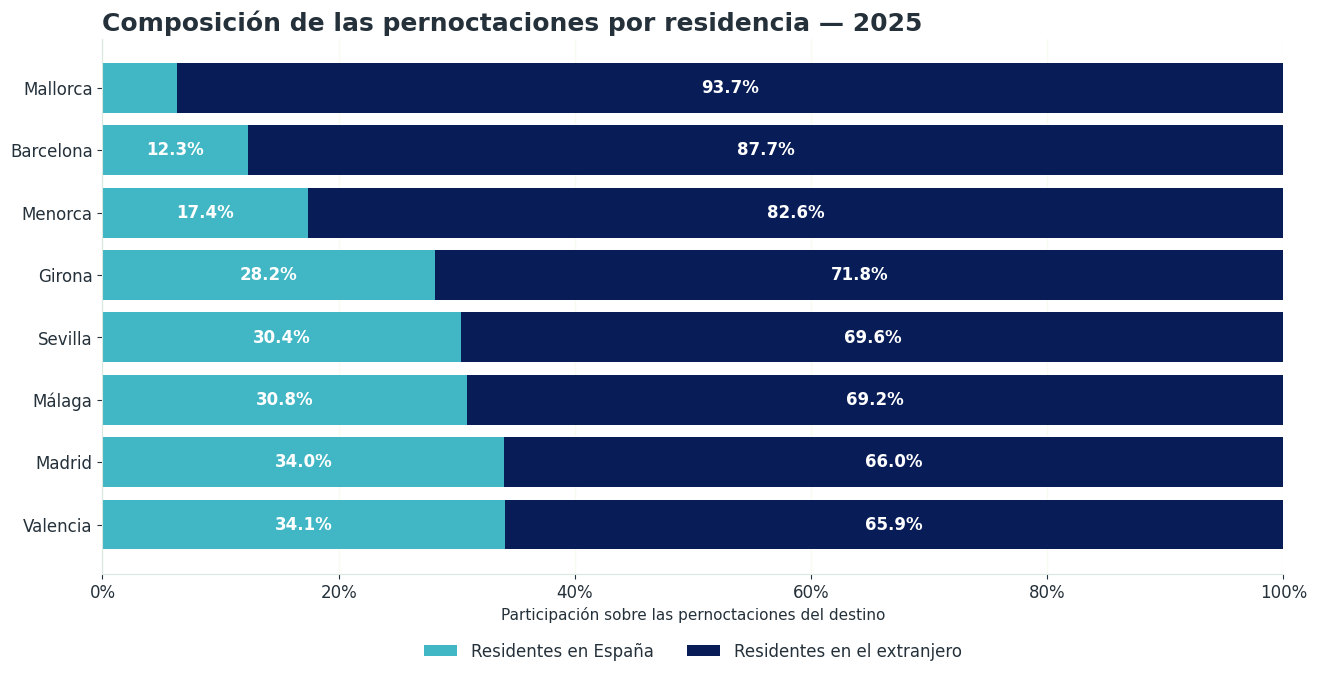

In [14]:
datos = tabla_maestra.sort_values("international_share_pct").copy()
fig, ax = plt.subplots(figsize=(13.33, 7.5))
ax.barh(datos["destination"], datos["national_share_pct"], color=CHART_TEAL, label="Residentes en España")
ax.barh(
    datos["destination"], datos["international_share_pct"],
    left=datos["national_share_pct"], color=CHART_DARK, label="Residentes en el extranjero",
)
for y, (_, fila) in enumerate(datos.iterrows()):
    if fila["national_share_pct"] >= 7:
        ax.text(fila["national_share_pct"] / 2, y, f"{fila['national_share_pct']:.1f}%", ha="center", va="center", color=WHITE, fontweight="bold")
    if fila["international_share_pct"] >= 7:
        ax.text(fila["national_share_pct"] + fila["international_share_pct"] / 2, y, f"{fila['international_share_pct']:.1f}%", ha="center", va="center", color=WHITE, fontweight="bold")
ax.set_title("Composición de las pernoctaciones por residencia — 2025", loc="left")
ax.set_xlabel("Participación sobre las pernoctaciones del destino")
ax.set_ylabel("")
ax.set_xlim(0, 100)
ax.xaxis.set_major_formatter(mticker.PercentFormatter())
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.10), ncol=2, frameon=False)
limpiar_ejes(ax, "x")
fig.tight_layout(rect=[0, 0.07, 1, 1])
guardar_figura(fig, "01_composicion_residencia_2025")


<a id="interpretacion-composicion"></a>
### 🔖 Interpretación — composición de las pernoctaciones por residencia

La demanda es mayoritariamente internacional en todos los destinos. Mallorca (**93,7%**), Barcelona (**87,7%**) y Menorca (**82,6%**) son los mercados con mayor dependencia del visitante extranjero. Madrid y Valencia presentan el mayor peso nacional, alrededor del **34%**, seguidos por Málaga y Sevilla, cerca del **30%**.

**Uso en la presentación:** separar una estrategia internacional prioritaria para Mallorca, Barcelona y Menorca de una estrategia mixta para los mercados urbanos.

> Los porcentajes del gráfico se refieren a **pernoctaciones**, no al motivo del viaje ni a reservas de StaySpain.

[↑ Volver al índice](#indice-graficos-matrices)

<a id="grafico-composicion-viajeros"></a>
### 11.2 Composición de viajeros por residencia

Este gráfico complementa la composición de **pernoctaciones** con la composición de **viajeros**.

[↑ Volver al índice](#indice-graficos-matrices)

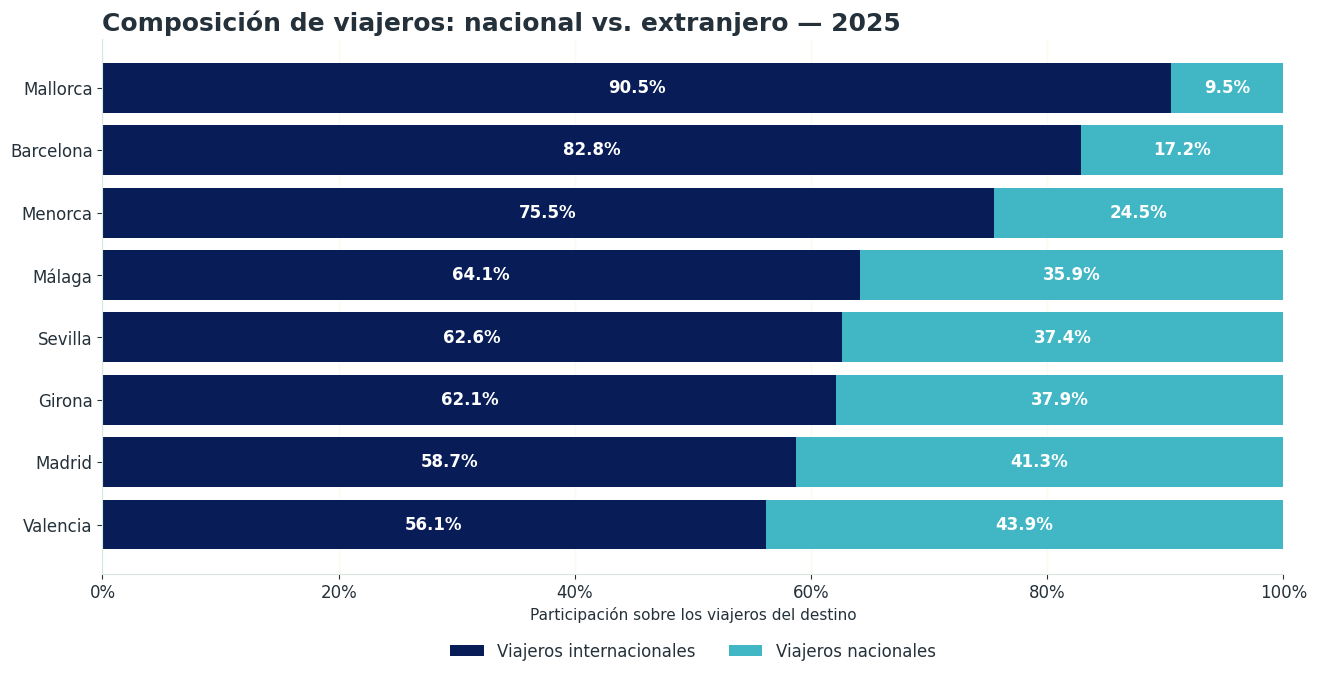

In [15]:
datos = tabla_maestra.copy()
datos["national_traveler_share_pct"] = (
    datos["national_travelers"] / datos["total_travelers"] * 100
)
datos["international_traveler_share_pct"] = (
    datos["international_travelers"] / datos["total_travelers"] * 100
)
datos = datos.sort_values("international_traveler_share_pct")

fig, ax = plt.subplots(figsize=(13.33, 7.5))
ax.barh(
    datos["destination"],datos["international_traveler_share_pct"],color=CHART_DARK,label="Viajeros internacionales",
)
ax.barh(
    datos["destination"],datos["national_traveler_share_pct"],left=datos["international_traveler_share_pct"],color=CHART_TEAL,label="Viajeros nacionales",
)

for y, (_, fila) in enumerate(datos.iterrows()):
    internacional = fila["international_traveler_share_pct"]
    nacional = fila["national_traveler_share_pct"]
    if pd.notna(internacional) and internacional >= 7:
        ax.text(
            internacional / 2,y,f"{internacional:.1f}%",ha="center",va="center",color=WHITE,fontweight="bold",
        )
    if pd.notna(nacional) and nacional >= 7:
        ax.text(
            internacional + nacional / 2,y,f"{nacional:.1f}%",ha="center",va="center",color=WHITE,fontweight="bold",
        )

ax.set_xlim(0, 100)
ax.set_title("Composición de viajeros: nacional vs. extranjero — 2025", loc="left")
ax.set_xlabel("Participación sobre los viajeros del destino")
ax.set_ylabel("")
ax.xaxis.set_major_formatter(mticker.PercentFormatter())
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.10), ncol=2)
limpiar_ejes(ax, "x")
fig.tight_layout(rect=[0, 0.07, 1, 1])
guardar_figura(fig, "composicion_viajeros_2025")

<a id="interpretacion-composicion-viajeros"></a>
### 🔖 Interpretación — perfil de viajeros nacional vs. extranjero

En los ocho destinos predominan los viajeros internacionales. El peso internacional es especialmente alto en Mallorca, Barcelona y Menorca; Madrid, Valencia, Málaga y Sevilla mantienen una participación nacional comparativamente mayor.

**Implicación:** la comunicación y adquisición internacional son prioritarias en los destinos con mayor dependencia exterior. En los mercados urbanos y mixtos, la procedencia por CCAA conserva relevancia para campañas nacionales.

> Este gráfico representa **viajeros**. No debe confundirse con la composición de **pernoctaciones**, porque una nacionalidad puede viajar menos veces pero permanecer más noches.

[↑ Volver al índice](#indice-graficos-matrices)


<a id="grafico-pernoctaciones"></a>
### 11.3 Volumen de pernoctaciones

[↑ Volver al índice](#indice-graficos-matrices)

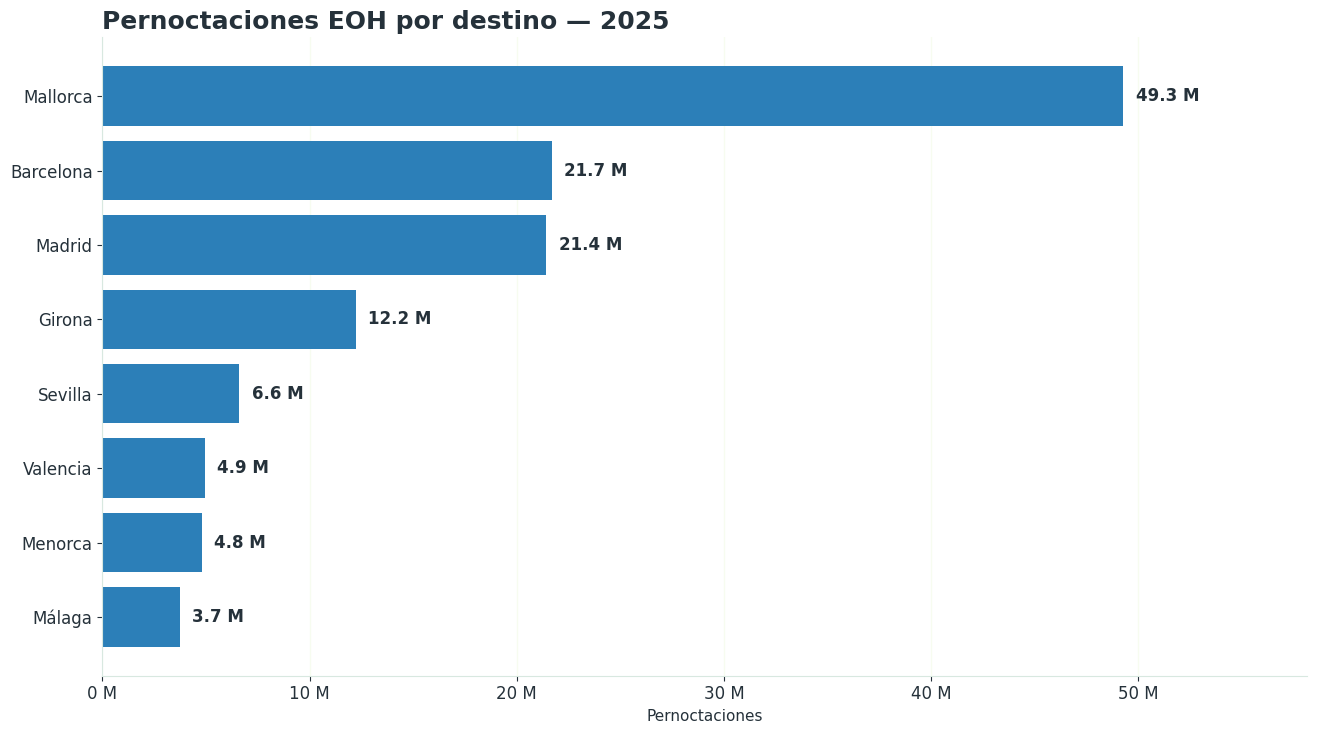

In [16]:
datos = tabla_maestra.sort_values("total_overnight_stays").copy()
fig, ax = plt.subplots(figsize=(13.33, 7.5))
barras = ax.barh(datos["destination"], datos["total_overnight_stays"], color=CHART_BLUE)
maximo = datos["total_overnight_stays"].max()
for barra, valor in zip(barras, datos["total_overnight_stays"]):
    ax.text(valor + maximo * 0.012, barra.get_y() + barra.get_height()/2, f"{valor/1e6:.1f} M", va="center", fontweight="bold")
ax.set_title("Pernoctaciones EOH por destino — 2025", loc="left")
ax.set_xlabel("Pernoctaciones")
ax.set_ylabel("")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1e6:.0f} M"))
ax.set_xlim(0, maximo * 1.18)
limpiar_ejes(ax, "x")
fig.tight_layout()
guardar_figura(fig, "02_pernoctaciones_por_destino_2025")


<a id="interpretacion-pernoctaciones"></a>
### 🔖 Interpretación — volumen de pernoctaciones

La demanda está muy concentrada:

- Mallorca: **49,3 millones** de pernoctaciones.
- Barcelona: **21,7 millones**.
- Madrid: **21,4 millones**.
- Girona/Costa Brava: **12,2 millones**.
- Sevilla: **6,6 millones**.
- Valencia, Menorca y Málaga: menos de **5 millones** cada uno.

**Conclusión:** Mallorca es el principal mercado por volumen; Barcelona y Madrid forman un segundo nivel de gran escala, y Girona ocupa una posición intermedia relevante.

[↑ Volver al índice](#indice-graficos-matrices)

<a id="grafico-estancia"></a>
### 11.4 Estancia media EOH vs. noches mínimas StaySpain

[↑ Volver al índice](#indice-graficos-matrices)

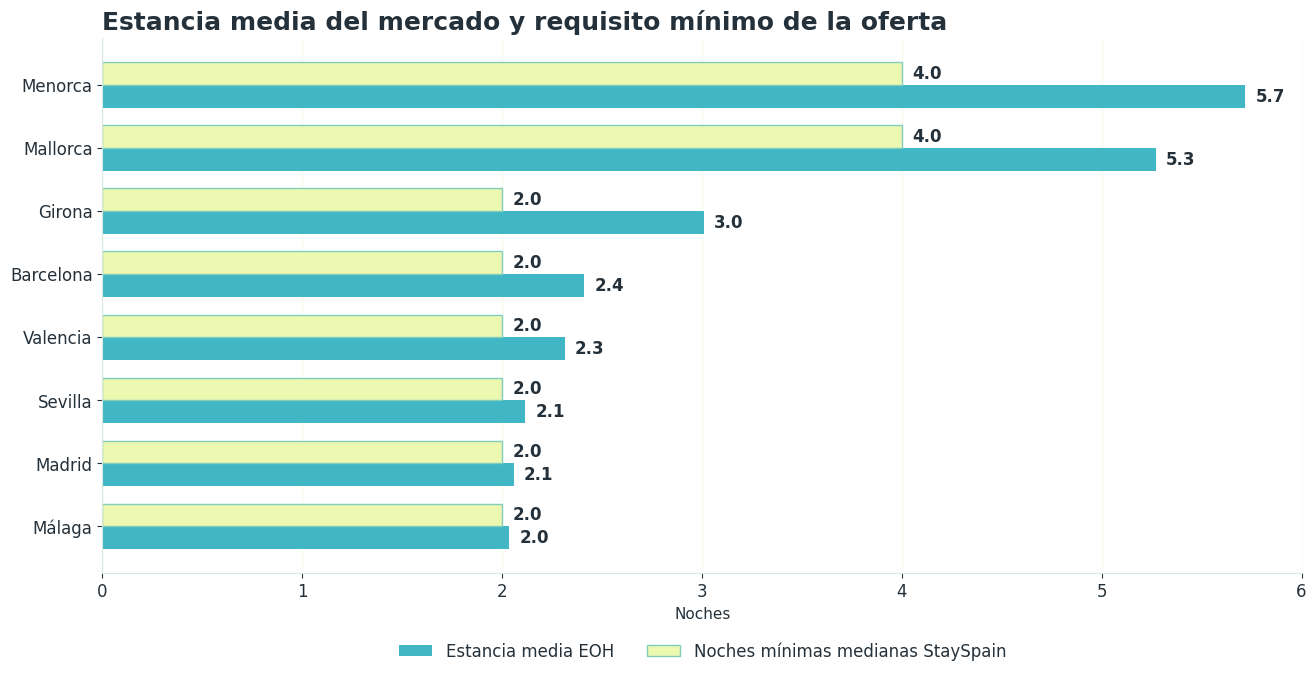

In [17]:
datos = tabla_maestra.sort_values("average_stay_total").copy()
y = np.arange(len(datos))
alto = 0.36
fig, ax = plt.subplots(figsize=(13.33, 7.5))
ax.barh(y - alto/2, datos["average_stay_total"], height=alto, color=CHART_TEAL, label="Estancia media EOH")
ax.barh(y + alto/2, datos["median_minimum_nights"], height=alto, color=CHART_LIGHT, edgecolor=CHART_GREEN, label="Noches mínimas medianas StaySpain")
for i, valor in enumerate(datos["average_stay_total"]):
    if pd.notna(valor): ax.text(valor + 0.05, i - alto/2, f"{valor:.1f}", va="center", fontweight="bold")
for i, valor in enumerate(datos["median_minimum_nights"]):
    if pd.notna(valor): ax.text(valor + 0.05, i + alto/2, f"{valor:.1f}", va="center", fontweight="bold")
ax.set_yticks(y)
ax.set_yticklabels(datos["destination"])
ax.set_title("Estancia media del mercado y requisito mínimo de la oferta", loc="left")
ax.set_xlabel("Noches")
ax.set_ylabel("")
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.10), ncol=2, frameon=False)
limpiar_ejes(ax, "x")
fig.tight_layout(rect=[0, 0.07, 1, 1])
guardar_figura(fig, "03_estancia_media_vs_noches_minimas")


<a id="interpretacion-estancia"></a>

### 5. 🔖 Interpretación — estancia media vs. noches mínimas

Los mercados insulares presentan las estancias medias más largas:

- Menorca: **5,72 noches** de estancia media EOH y **4 noches mínimas medianas** en StaySpain.
- Mallorca: **5,27 noches** y **4 noches mínimas**.
- Girona: **3,01 noches** y **2 noches mínimas**.
- Los destinos urbanos se sitúan aproximadamente entre **2,0 y 2,4 noches**, con una mediana de **2 noches mínimas**.

Los mínimos medianos de StaySpain no superan la estancia media hotelera observada en ninguno de los ocho destinos. Esto sugiere que no existe una incompatibilidad evidente a nivel agregado.

> La comparación es únicamente descriptiva: EOH representa estancias hoteleras y StaySpain otra tipología de alojamiento. Además, los dos datasets no necesariamente corresponden al mismo periodo. Por ello, estos resultados no permiten definir por sí solos el número óptimo de noches mínimas.

[↑ Volver al índice](#indice-graficos-matrices)

<a id="grafico-heatmap"></a>
### 11.5 Heatmap de estacionalidad — 2025

[↑ Volver al índice](#indice-graficos-matrices)

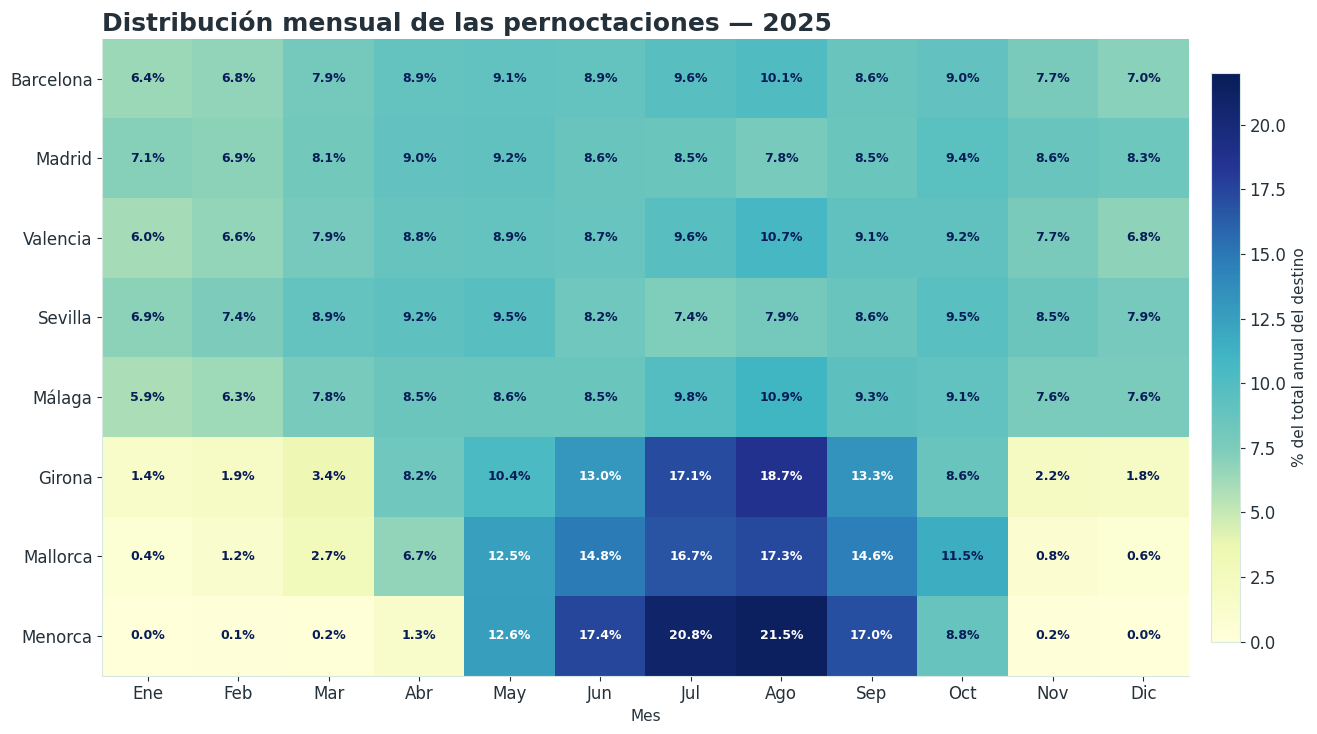

In [18]:
heat = (
    serie_mensual[
        (serie_mensual["anio"] == ANIO_PRINCIPAL)
        & (serie_mensual["residence_group"] == "Total")
    ]
    .pivot_table(index="destination", columns="month", values="annual_share_pct", aggfunc="sum")
    .reindex(index=MERCADOS, columns=range(1, 13))
)

fig, ax = plt.subplots(figsize=(13.33, 7.5))
im = ax.imshow(heat.values, aspect="auto", cmap=HEATMAP_CMAP,
    vmin=0,
    vmax=22,
)
ax.set_xticks(range(12))
ax.set_xticklabels(["Ene", "Feb", "Mar", "Abr", "May", "Jun", "Jul", "Ago", "Sep", "Oct", "Nov", "Dic"])
ax.set_yticks(range(len(heat.index)))
ax.set_yticklabels(heat.index)
for i in range(heat.shape[0]):
    for j in range(heat.shape[1]):
        valor = heat.iloc[i, j]
        if pd.notna(valor):
            color = WHITE if valor >= 12 else NAVY
            ax.text(j, i, f"{valor:.1f}%", ha="center", va="center", fontsize=9, color=color, fontweight="bold")
ax.set_title("Distribución mensual de las pernoctaciones — 2025", loc="left")
ax.set_xlabel("Mes")
ax.set_ylabel("")
barra = fig.colorbar(im, ax=ax, fraction=0.025, pad=0.02)
barra.set_label("% del total anual del destino")
fig.tight_layout()
guardar_figura(fig, "04_heatmap_estacionalidad_2025")


<a id="interpretacion-heatmap"></a>
### 🔖 Interpretación — heatmap de estacionalidad

Mallorca, Menorca y Girona muestran una estacionalidad claramente superior, con máximo en agosto. Menorca presenta la mayor concentración anual en pocos meses (**59,7%**), mientras que Girona y Mallorca se sitúan cerca del **49%**.

Madrid y Sevilla tienen picos diferentes —octubre y mayo— y una distribución más estable. Barcelona, Valencia y Málaga también muestran menor concentración que los mercados insulares.

**Implicación:** la planificación de campañas, precios y captación debe ser más estacional en los destinos vacacionales y más continua en los destinos urbanos.

[↑ Volver al índice](#indice-graficos-matrices)

<a id="grafico-heatmap-2023-2025"></a>
### 11.6 Heatmap medio de temporalidad — 2023–2025

Este heatmap no sustituye al de 2025: muestra la participación mensual media de los tres años.

[↑ Volver al índice](#indice-graficos-matrices)

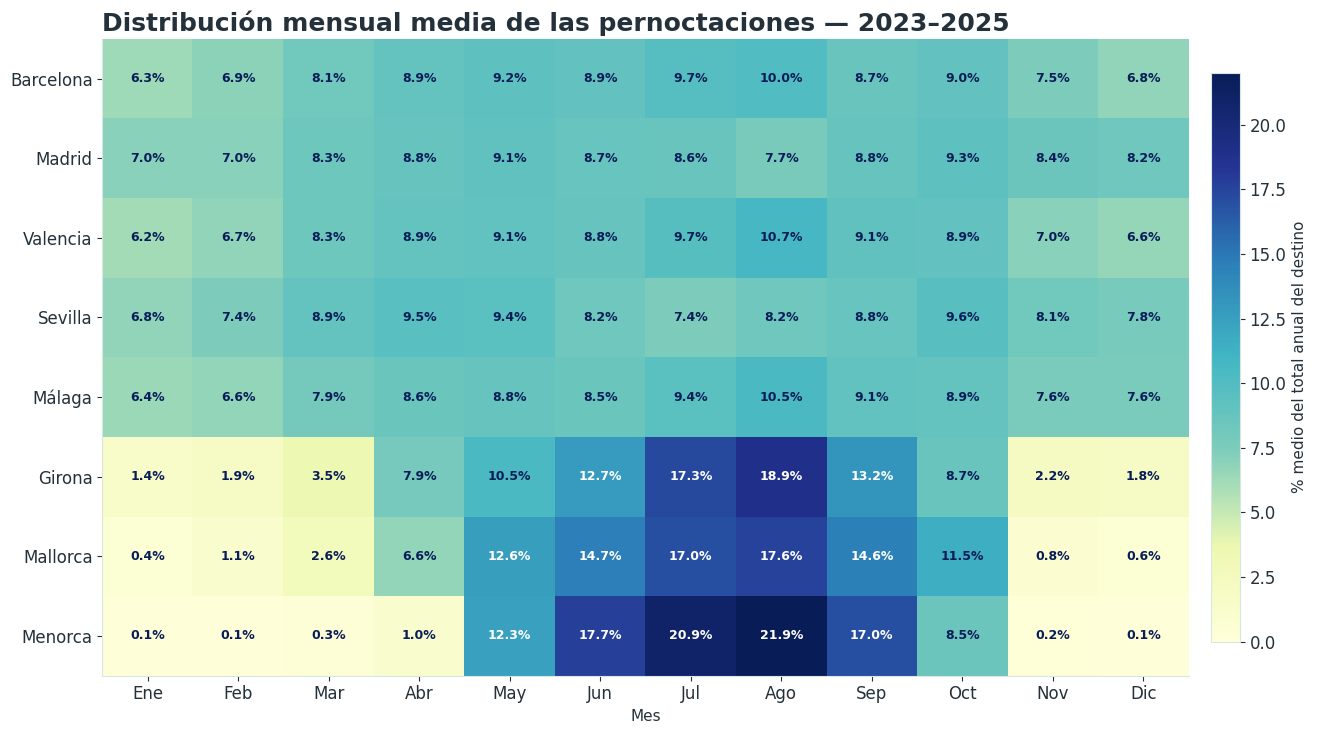

In [19]:
patron_2023_2025 = (
    serie_mensual[
        (serie_mensual["residence_group"] == "Total")
        & (serie_mensual["anio"].isin(ANIOS_ESTABILIDAD))
    ]
    .groupby(["destination", "month"], as_index=False)["annual_share_pct"]
    .mean()
)

heat_promedio = (
    patron_2023_2025
    .pivot_table(index="destination",columns="month",values="annual_share_pct",aggfunc="mean",)
    .reindex(index=MERCADOS, columns=range(1, 13)))

fig, ax = plt.subplots(figsize=(13.33, 7.5))
im = ax.imshow(heat_promedio.values, aspect="auto", cmap=HEATMAP_CMAP,vmin=0,vmax=22,)

ax.set_xticks(range(12))
ax.set_xticklabels(
    ["Ene", "Feb", "Mar", "Abr", "May", "Jun",
     "Jul", "Ago", "Sep", "Oct", "Nov", "Dic"]
)
ax.set_yticks(range(len(heat_promedio.index)))
ax.set_yticklabels(heat_promedio.index)

umbral_texto = 12
for i in range(heat_promedio.shape[0]):
    for j in range(heat_promedio.shape[1]):
        valor = heat_promedio.iloc[i, j]
        if pd.notna(valor):
            ax.text(j,i,f"{valor:.1f}%",ha="center",va="center",fontsize=9,color=WHITE if valor >= 12 else NAVY,fontweight="bold",)

ax.set_title("Distribución mensual media de las pernoctaciones — 2023–2025",loc="left",)
ax.set_xlabel("Mes")
ax.set_ylabel("")
barra = fig.colorbar(im, ax=ax, fraction=0.025, pad=0.02)
barra.set_label("% medio del total anual del destino")
fig.tight_layout()
guardar_figura(fig, "heatmap_temporalidad_media_2023_2025")

<a id="interpretacion-heatmap-2023-2025"></a>
### 🔖 Interpretación — temporalidad media 2023–2025

La media de tres años distingue dos comportamientos:

- Mallorca, Menorca y Girona muestran el patrón más vacacional, con fuerte concentración en verano.
- Los mercados urbanos presentan distribuciones mensuales más estables.
- Madrid y Sevilla pueden tener meses pico distintos de los destinos insulares y costeros.

**Implicación:** los mercados vacacionales necesitan campañas, disponibilidad y captación más dependientes de temporada; los urbanos permiten una estrategia más continua.

> La media 2023–2025 suaviza anomalías anuales. Por eso no reemplaza al heatmap específico de 2025.

[↑ Volver al índice](#indice-graficos-matrices)


<a id="grafico-oferta-demanda"></a>
### 11.7 Participación de oferta vs. demanda

[↑ Volver al índice](#indice-graficos-matrices)

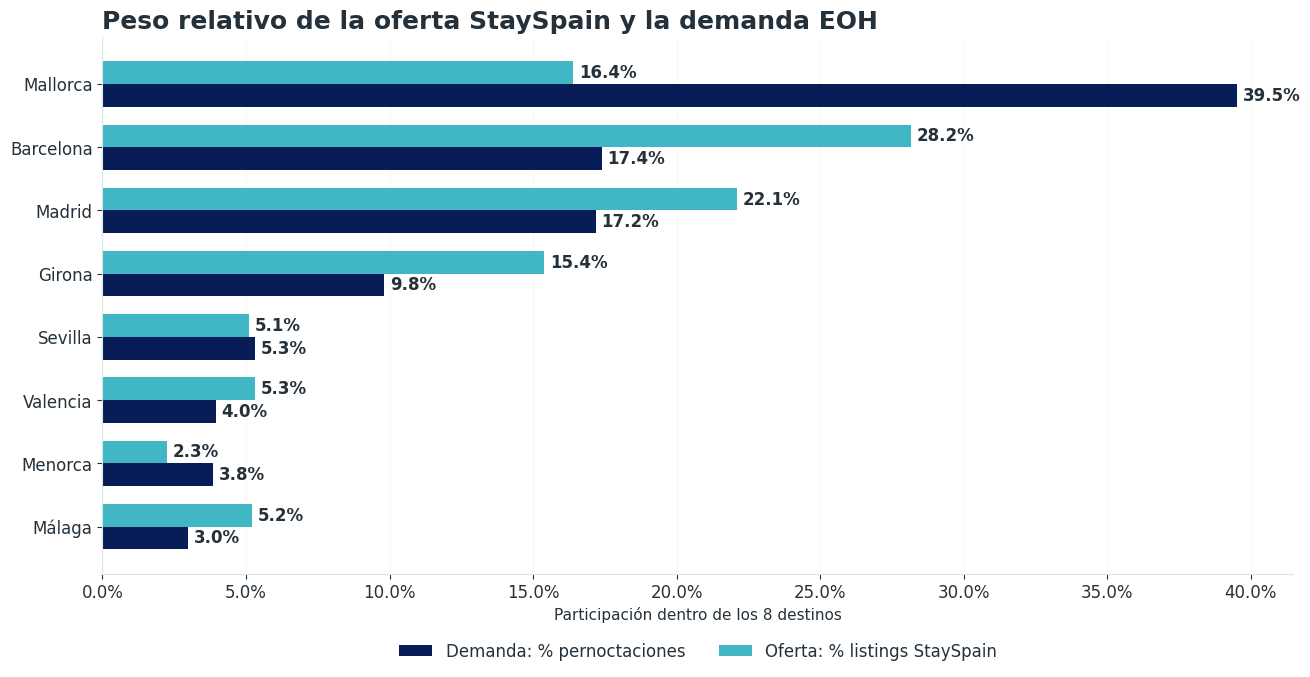

In [20]:
datos = tabla_maestra.sort_values("demand_share_pct", ascending=True).copy()
y = np.arange(len(datos))
alto = 0.36
fig, ax = plt.subplots(figsize=(13.33, 7.5))
ax.barh(y - alto/2, datos["demand_share_pct"], height=alto, color=CHART_DARK, label="Demanda: % pernoctaciones")
ax.barh(y + alto/2, datos["supply_share_pct"], height=alto, color=CHART_TEAL, label="Oferta: % listings StaySpain")
for i, valor in enumerate(datos["demand_share_pct"]):
    ax.text(valor + 0.2, i - alto/2, f"{valor:.1f}%", va="center", fontweight="bold")
for i, valor in enumerate(datos["supply_share_pct"]):
    ax.text(valor + 0.2, i + alto/2, f"{valor:.1f}%", va="center", fontweight="bold")
ax.set_yticks(y)
ax.set_yticklabels(datos["destination"])
ax.set_title("Peso relativo de la oferta StaySpain y la demanda EOH", loc="left")
ax.set_xlabel("Participación dentro de los 8 destinos")
ax.set_ylabel("")
ax.xaxis.set_major_formatter(mticker.PercentFormatter())
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.10), ncol=2, frameon=False)
limpiar_ejes(ax, "x")
fig.tight_layout(rect=[0, 0.07, 1, 1])
guardar_figura(fig, "05_participacion_oferta_vs_demanda")


<a id="interpretacion-oferta-demanda"></a>
### 🔖 Interpretación — participación de oferta vs. demanda

Mallorca concentra **39,5% de la demanda**, pero solo **16,4% de la oferta StaySpain**, el mayor desajuste del conjunto. Barcelona presenta la situación contraria: **17,4% de demanda** y **28,2% de oferta**. Madrid y Girona también tienen un peso de oferta superior al de demanda.

Sevilla es el destino más equilibrado, con **5,3% de demanda** y **5,1% de oferta**.

> Este contraste usa participaciones relativas dentro de los ocho destinos y no demuestra escasez o exceso absoluto de alojamientos.

[↑ Volver al índice](#indice-graficos-matrices)

<a id="grafico-opportunity-matrix"></a>
### 11.8 Opportunity Matrix de cuadrantes

[↑ Volver al índice](#indice-graficos-matrices)

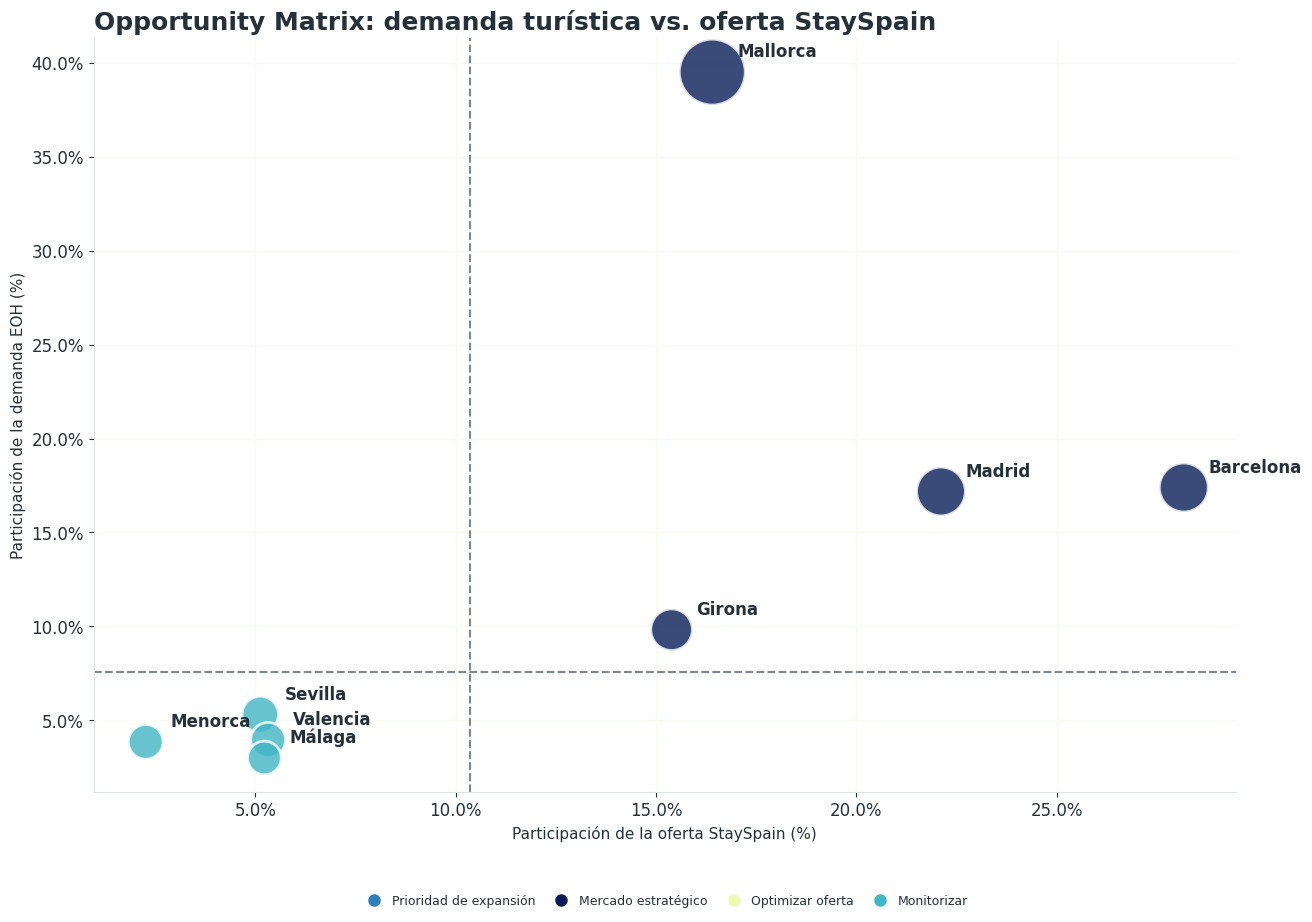

In [21]:
datos = tabla_maestra.dropna(subset=["supply_share_pct", "demand_share_pct"]).copy()
fig, ax = plt.subplots(figsize=(13.33, 10.5))
max_volumen = datos["total_overnight_stays"].max()
tamanos = 450 + 1800 * datos["total_overnight_stays"] / max_volumen

colores_cuadrante = {
    "Prioridad de expansión": STATUS_EXPANSION,
    "Mercado estratégico": STATUS_STRATEGIC,
    "Optimizar oferta": STATUS_OPTIMIZE,
    "Monitorizar": STATUS_MONITOR,
}
for cuadrante, grupo in datos.groupby("strategic_quadrant"):
    ax.scatter(
        grupo["supply_share_pct"], grupo["demand_share_pct"],
        s=tamanos.loc[grupo.index], color=colores_cuadrante[cuadrante],
        alpha=0.8, edgecolor=WHITE, linewidth=2, label=cuadrante,
    )

for _, fila in datos.iterrows():
    ax.annotate(
        fila["destination"],
        (fila["supply_share_pct"], fila["demand_share_pct"]),
        xytext=(18,11), textcoords="offset points", fontweight="bold", fontsize=12,
    )

ax.axvline(mediana_oferta, color=GREY, linestyle="--", linewidth=1.5)
ax.axhline(mediana_demanda, color=GREY, linestyle="--", linewidth=1.5)
ax.set_title("Opportunity Matrix: demanda turística vs. oferta StaySpain", loc="left")
ax.set_xlabel("Participación de la oferta StaySpain (%)")
ax.set_ylabel("Participación de la demanda EOH (%)")
ax.xaxis.set_major_formatter(mticker.PercentFormatter())
ax.yaxis.set_major_formatter(mticker.PercentFormatter())
from matplotlib.lines import Line2D
handles = [
    Line2D([0], [0], marker="o", linestyle="", markerfacecolor=color,
           markeredgecolor=WHITE, markersize=10, label=etiqueta)
    for etiqueta, color in colores_cuadrante.items()
]
ax.legend(handles=handles, loc="upper center", bbox_to_anchor=(0.5, -0.12),
          ncol=4, frameon=False, fontsize=9, handletextpad=0.4, columnspacing=1.1)
limpiar_ejes(ax, "both")
fig.tight_layout(rect=[0, 0.10, 1, 1])
guardar_figura(fig, "06_opportunity_matrix")


<a id="interpretacion-opportunity-matrix"></a>

### 9. 🔖 Interpretación — Opportunity Matrix de cuadrantes

La matriz clasifica los destinos según su posición relativa respecto a las medianas de demanda y oferta de los ocho mercados.

Mallorca aparece como **Mercado estratégico**, porque tanto su participación de demanda como su participación de oferta están por encima de las medianas. Sin embargo, su brecha demanda − oferta alcanza **+23,1 pp**, lo que indica que su peso en la demanda es muy superior a su peso en la oferta StaySpain.

Barcelona, Madrid y Girona también aparecen como mercados estratégicos por su escala, aunque presentan brechas negativas y una presencia relativa de oferta más elevada.

Menorca, Sevilla, Valencia y Málaga se sitúan por debajo de las medianas de escala y requieren seguimiento o actuaciones selectivas.

**Lectura correcta:** el cuadrante refleja la escala relativa del mercado, mientras que la brecha mide el desajuste entre demanda y oferta. Ambos indicadores deben interpretarse conjuntamente.

> La Opportunity Matrix es una herramienta descriptiva propuesta por el equipo. No demuestra causalidad, escasez real, rentabilidad ni necesidad automática de inversión.

[↑ Volver al índice](#indice-graficos-matrices)

<a id="matriz-evidencia"></a>
### 11.9 Matriz de evidencia por destino

Matriz individual antes de agrupar conclusiones.

[↑ Volver al índice](#indice-graficos-matrices)

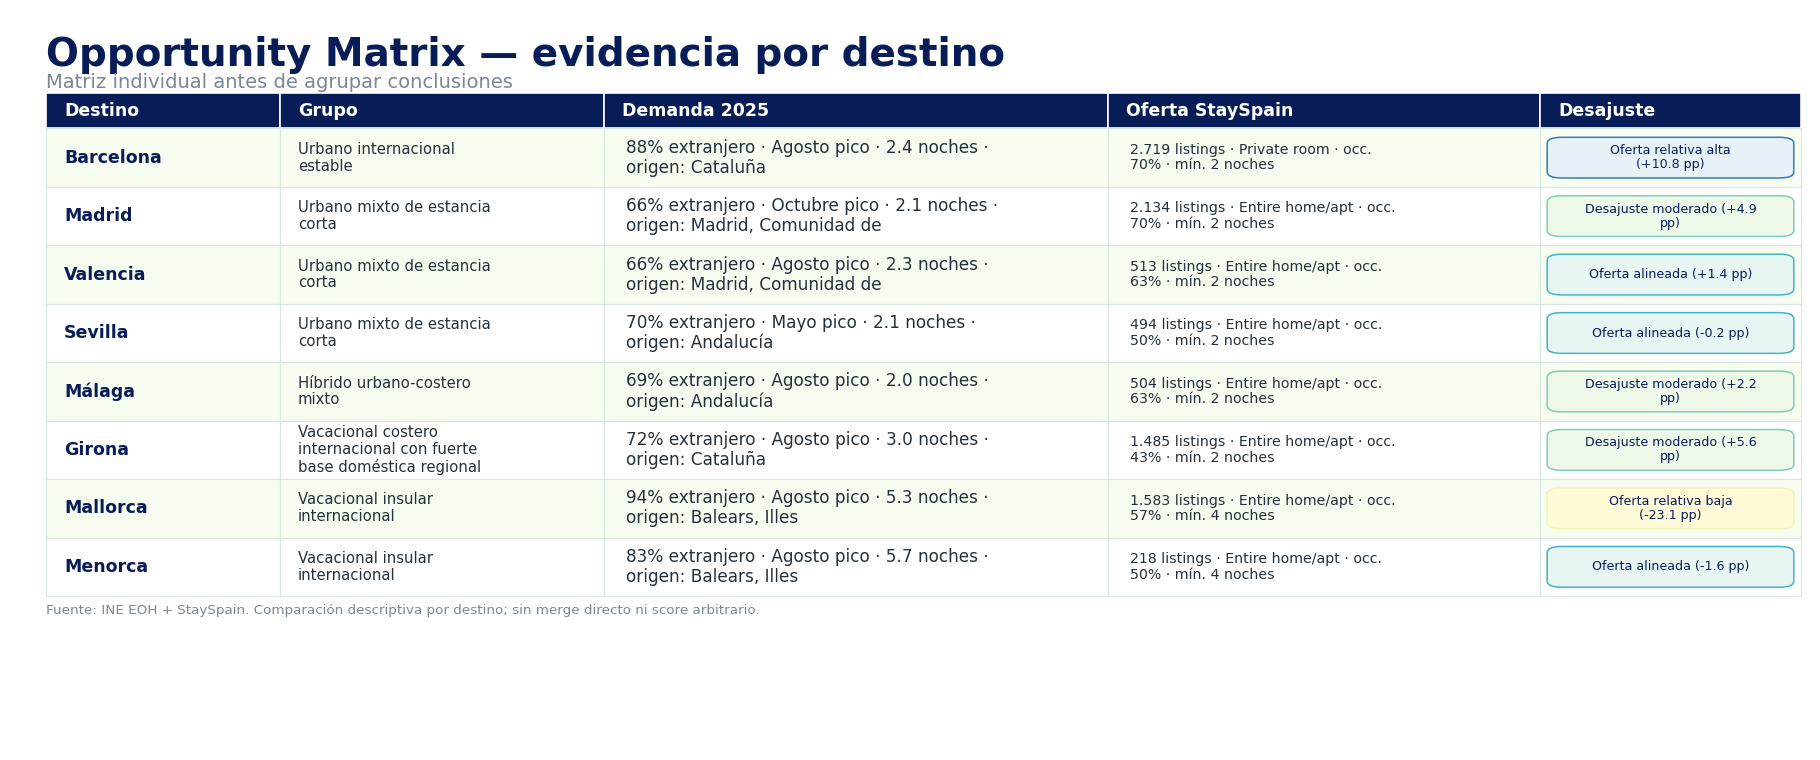

In [22]:
def crear_matriz_evidencia():
    fig = plt.figure(figsize=(18, 7.4), facecolor=WHITE)
    ax = fig.add_axes([0, 0, 1, 1])
    ax.set_axis_off()
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    # --------------------------------------------------------
    ax.text(0.02,0.965,"Opportunity Matrix — evidencia por destino",
        transform=ax.transAxes,fontsize=28,fontweight="bold",color=NAVY,ha="left",va="top",)

    ax.text(0.02,0.915,"Matriz individual antes de agrupar conclusiones",transform=ax.transAxes,fontsize=14,color=GREY,ha="left",va="top",)
    # --------------------------------------------------------
    x_inicial = 0.02

    columnas = [("Destino", 0.130),("Grupo", 0.180),("Demanda 2025", 0.280),("Oferta StaySpain", 0.240),("Desajuste", 0.145),]

    posiciones_x = []
    x_actual = x_inicial

    for nombre, ancho in columnas:
        posiciones_x.append((nombre, x_actual, ancho))
        x_actual += ancho

    y_cabecera = 0.840
    alto_cabecera = 0.048
    alto_fila = 0.079

    # --------------------------------------------------------
    # Cabecera
    # --------------------------------------------------------
    for nombre, x, ancho in posiciones_x:
        ax.add_patch(Rectangle((x, y_cabecera),ancho,alto_cabecera,transform=ax.transAxes,facecolor=NAVY,edgecolor=WHITE,linewidth=1.2,clip_on=False,))
        ax.text(x + 0.010,y_cabecera + alto_cabecera / 2,nombre,transform=ax.transAxes,fontsize=12.5,color=WHITE,fontweight="bold",ha="left",va="center",)

    def texto_valido(valor, defecto="N/D"):
        return defecto if pd.isna(valor) else str(valor)

    # --------------------------------------------------------
    # Filas
    # --------------------------------------------------------
    for i, fila in master.reset_index(drop=True).iterrows():
        y = y_cabecera - (i + 1) * alto_fila
        centro_y = y + alto_fila / 2

        relleno = LIGHT_GREY if i % 2 == 0 else WHITE
        gap = fila["supply_vs_demand_gap_pp"]

        if pd.isna(gap):
            color_badge = LIGHT_GREY
            borde_badge = GREY

        elif gap <= -8:
            color_badge = PALE_YELLOW
            borde_badge = STATUS_NEGATIVE

        elif gap >= 8:
            color_badge = PALE_BLUE
            borde_badge = STATUS_POSITIVE

        elif abs(gap) <= 2:
            color_badge = PALE_TEAL
            borde_badge = STATUS_NEUTRAL

        else:
            color_badge = PALETTE["pale_green"]
            borde_badge = CHART_GREEN

        for _, x, ancho in posiciones_x:
            ax.add_patch(Rectangle((x, y),ancho,alto_fila,transform=ax.transAxes,facecolor=relleno,edgecolor=BORDER,linewidth=0.8,clip_on=False,))

        # ----------------------------------------------------
        # Destino
        # ----------------------------------------------------
        x_destino = posiciones_x[0][1]

        ax.text(x_destino + 0.010,centro_y,texto_valido(fila["destination"]),transform=ax.transAxes,fontsize=12.5,
                fontweight="bold",color=NAVY,ha="left",va="center",)

        # ----------------------------------------------------
        # Grupo
        # ----------------------------------------------------
        x_grupo = posiciones_x[1][1]

        grupo_texto = textwrap.fill(texto_valido(fila["market_group"]),width=25,)

        ax.text(x_grupo + 0.010,centro_y,grupo_texto,transform=ax.transAxes,fontsize=10.7,color=DARK,ha="left",va="center",linespacing=1.15,)

        # ----------------------------------------------------
        # Demanda
        # ----------------------------------------------------
        cuota_internacional = (
            f"{fila['international_share_pct']:.0f}% extranjero"
            if pd.notna(fila["international_share_pct"])
            else "extranjero N/D"
        )

        mes_pico = texto_valido(fila["peak_month_total"],"mes pico N/D",)

        estancia = (f"{fila['average_stay_total']:.1f} noches"
            if pd.notna(fila["average_stay_total"])
            else "estancia N/D"
        )

        origen = texto_valido(fila["top_origin_ccaa"],"origen N/D",)

        demanda_texto = (
            f"{cuota_internacional} · "
            f"{mes_pico} pico · "
            f"{estancia} · "
            f"origen: {origen}"
        )

        demanda_texto = textwrap.fill(demanda_texto,width=47,)

        x_demanda = posiciones_x[2][1]

        ax.text(x_demanda + 0.012,centro_y,demanda_texto,transform=ax.transAxes,fontsize=12.2,color=DARK,ha="left",va="center",linespacing=1.15,)

        # ----------------------------------------------------
        # Oferta StaySpain
        # ----------------------------------------------------
        listings = (
            f"{int(fila['unique_listings']):,}".replace(",", ".")
            + " listings"
            if pd.notna(fila["unique_listings"])
            else "listings N/D"
        )

        tipo_alojamiento = texto_valido(fila["dominant_room_type"],"tipo N/D",)

        ocupacion = (f"occ. {fila['median_occupancy_pct']:.0f}%"
            if pd.notna(fila.get("median_occupancy_pct"))
            else "occ. N/D"
        )

        minimo = (f"mín. {fila['median_minimum_nights']:.0f} noches"
            if pd.notna(fila["median_minimum_nights"])
            else "mín. N/D"
        )

        oferta_texto = (
            f"{listings} · "
            f"{tipo_alojamiento} · "
            f"{ocupacion} · "
            f"{minimo}"
        )

        oferta_texto = textwrap.fill(oferta_texto,width=39,
)
        x_oferta = posiciones_x[3][1]

        ax.text(x_oferta + 0.012,centro_y,oferta_texto,transform=ax.transAxes,fontsize=10.2,color=DARK,ha="left",va="center",linespacing=1.15,)

        # ----------------------------------------------------
        # Desajuste — Badge
        # ----------------------------------------------------
        x_badge = posiciones_x[4][1]
        ancho_badge_columna = posiciones_x[4][2]

        margen_x = 0.008
        margen_y = 0.016

        ax.add_patch(
            FancyBboxPatch(
                (
                    x_badge + margen_x,
                    y + margen_y,
                ),
                ancho_badge_columna - 2 * margen_x,
                alto_fila - 2 * margen_y,
                boxstyle="round,pad=0.004,rounding_size=0.008",transform=ax.transAxes,facecolor=color_badge,edgecolor=borde_badge,
                linewidth=1.1,clip_on=False,
            )
        )

        texto_desajuste = textwrap.fill(
            texto_valido(fila["identified_mismatch"],"Sin datos suficientes",
            ),
            width=25,
        )

        ax.text(
            x_badge + ancho_badge_columna / 2,centro_y,texto_desajuste,
            transform=ax.transAxes,fontsize=9.1,color=NAVY,ha="center",va="center",linespacing=1.1,
        )

    # --------------------------------------------------------
    # Fuente
    # --------------------------------------------------------
    ax.text(0.02,0.18,
        ("Fuente: INE EOH + StaySpain. Comparación descriptiva por destino; "
            "sin merge directo ni score arbitrario."
        ),
        transform=ax.transAxes,fontsize=9.7,color=GREY,ha="left",va="bottom",)

    guardar_figura(fig,"matriz_evidencia",)

crear_matriz_evidencia()

<a id="interpretacion-matrix-evidencia"></a>
### 🔖 Interpretación — Opportunity Matrix de evidencia

La matriz muestra que los destinos no comparten el mismo patrón:

- Mallorca combina gran volumen de demanda, fuerte peso internacional, estancia larga y menor peso relativo de oferta.
- Barcelona, Madrid y Girona tienen escala relevante tanto en demanda como en presencia de StaySpain.
- Menorca presenta estancias largas y elevada estacionalidad, pero menor escala.
- Sevilla, Valencia y Málaga muestran relaciones oferta–demanda más próximas al equilibrio relativo.

**Conclusión:** primero debe analizarse cada destino y después agrupar conclusiones por mercados urbanos, costeros e insulares.

[↑ Volver al índice](#indice-graficos-matrices)


<a id="matriz-acciones"></a>
### 11.10 Matriz de decisión y acción

Recomendaciones basadas en evidencia descriptiva, no causal.

[↑ Volver al índice](#indice-graficos-matrices)

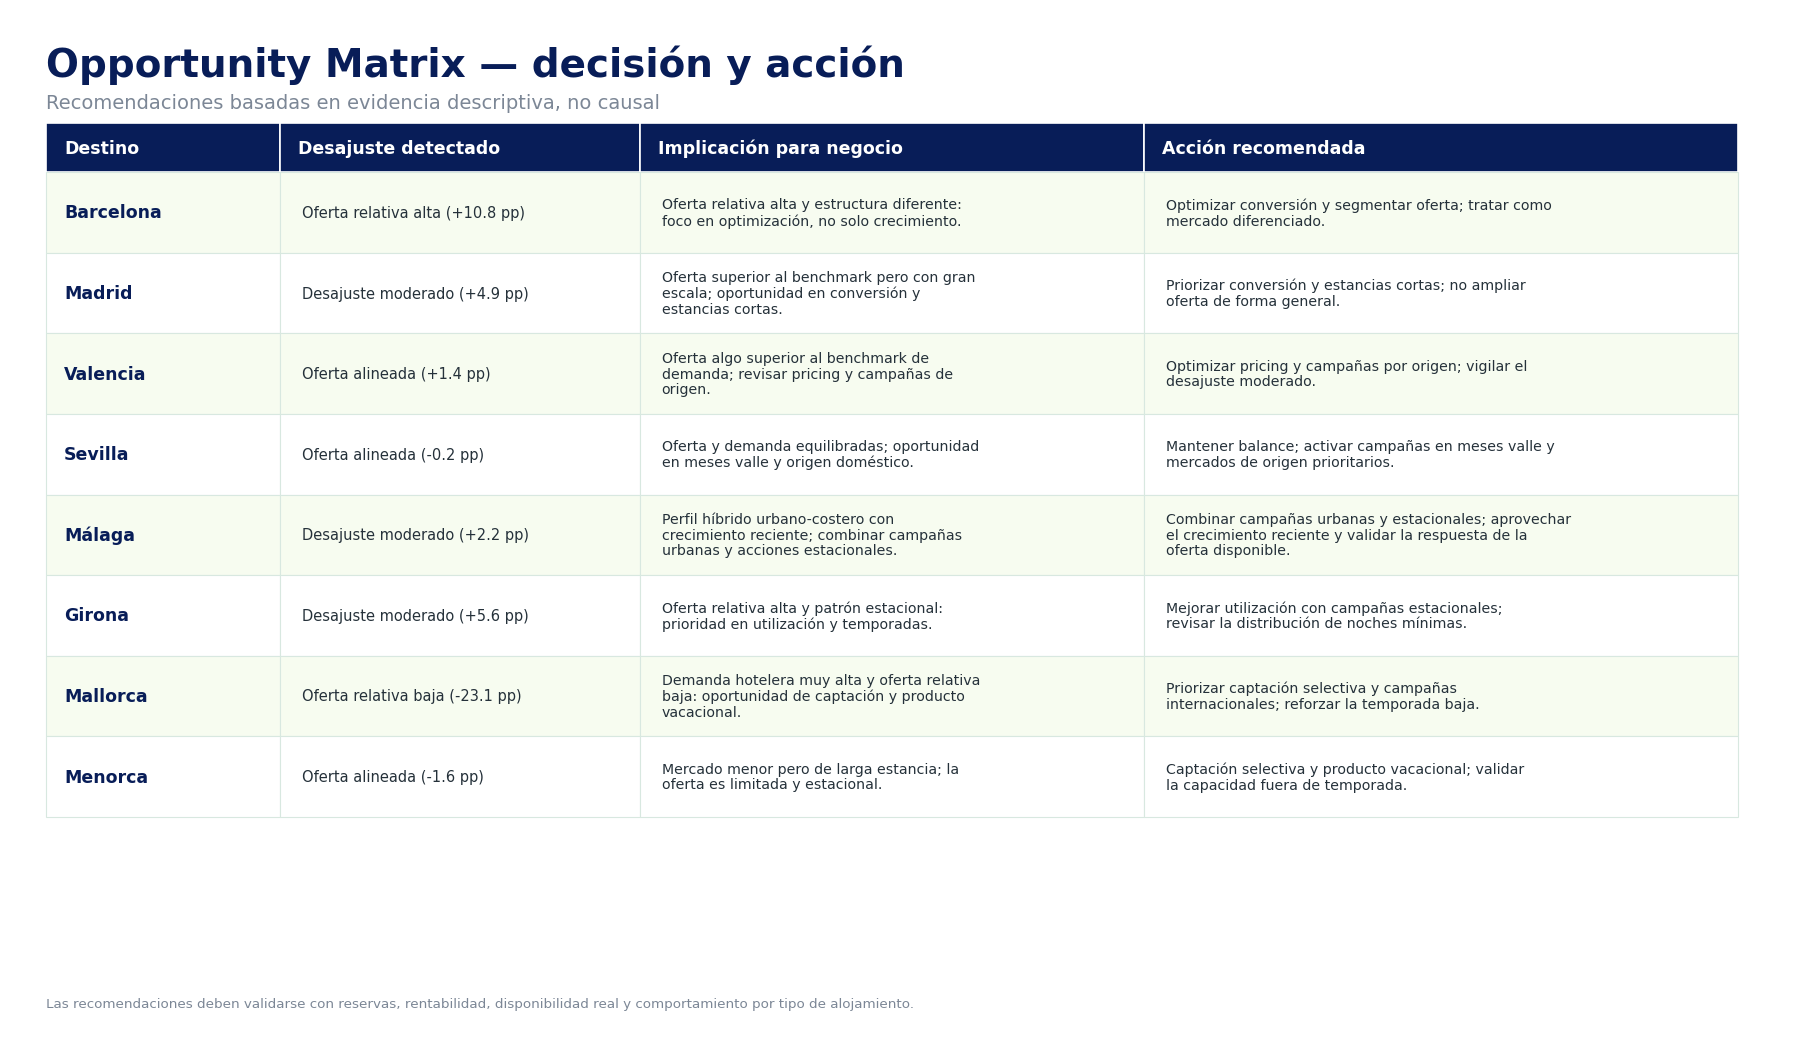

In [23]:
def crear_matriz_acciones():
    implicaciones = {
        "Mallorca": "Demanda hotelera muy alta y oferta relativa baja: oportunidad de captación y producto vacacional.",
        "Barcelona": "Oferta relativa alta y estructura diferente: foco en optimización, no solo crecimiento.",
        "Menorca": "Mercado menor pero de larga estancia; la oferta es limitada y estacional.",
        "Girona": "Oferta relativa alta y patrón estacional: prioridad en utilización y temporadas.",
        "Málaga": "Perfil híbrido urbano-costero con crecimiento reciente; combinar campañas urbanas y acciones estacionales.",
        "Sevilla": "Oferta y demanda equilibradas; oportunidad en meses valle y origen doméstico.",
        "Valencia": "Oferta algo superior al benchmark de demanda; revisar pricing y campañas de origen.",
        "Madrid": "Oferta superior al benchmark pero con gran escala; oportunidad en conversión y estancias cortas.",
    }

    fig = plt.figure(figsize=(18, 10.2), facecolor=WHITE)
    ax = fig.add_axes([0, 0, 1, 1])
    ax.set_axis_off()
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)

    # --------------------------------------------------------
    # Título
    # --------------------------------------------------------
    ax.text(0.02,0.965,"Opportunity Matrix — decisión y acción",transform=ax.transAxes,fontsize=28,fontweight="bold",color=NAVY,ha="left",va="top",)

    ax.text(0.02,0.918,"Recomendaciones basadas en evidencia descriptiva, no causal",transform=ax.transAxes,fontsize=14,color=GREY,ha="left",va="top",)

    # --------------------------------------------------------
    # Columnas
    # --------------------------------------------------------
    x_inicial = 0.02
    columnas = [("Destino", 0.13),("Desajuste detectado", 0.20),("Implicación para negocio", 0.28),("Acción recomendada", 0.33),]

    posiciones_x = []
    x_actual = x_inicial
    for nombre, ancho in columnas:
        posiciones_x.append((nombre, x_actual, ancho))
        x_actual += ancho

    y_cabecera = 0.84
    alto_cabecera = 0.048
    alto_fila = 0.079

    # --------------------------------------------------------
    # Header
    # --------------------------------------------------------
    for nombre, x, ancho in posiciones_x:
        ax.add_patch(Rectangle((x, y_cabecera),ancho,alto_cabecera,transform=ax.transAxes,facecolor=NAVY,edgecolor=WHITE,linewidth=1.2,clip_on=False,))

        ax.text(x + 0.01,y_cabecera + alto_cabecera / 2,nombre,transform=ax.transAxes,fontsize=12.5,color=WHITE,fontweight="bold",ha="left",va="center",)

    # --------------------------------------------------------
    # Filas
    # --------------------------------------------------------
    for i, fila in master.reset_index(drop=True).iterrows():
        y = y_cabecera - (i + 1) * alto_fila
        centro_y = y + alto_fila / 2
        relleno = LIGHT_GREY if i % 2 == 0 else WHITE

        for _, x, ancho in posiciones_x:
            ax.add_patch(Rectangle((x, y),ancho,alto_fila,transform=ax.transAxes,facecolor=relleno,edgecolor=BORDER,linewidth=0.8,clip_on=False,))

        # ---------------------------
        # Destino
        # ---------------------------
        x_destino = posiciones_x[0][1]
        ax.text(x_destino + 0.01,centro_y,str(fila["destination"]),transform=ax.transAxes,fontsize=12.5,fontweight="bold",color=NAVY,ha="left",va="center",)

        # ---------------------------
        # Desajuste detectado
        # ---------------------------
        x_desajuste = posiciones_x[1][1]
        texto_desajuste = textwrap.fill(str(fila["identified_mismatch"]),width=32,)

        ax.text(x_desajuste + 0.012,centro_y,texto_desajuste,transform=ax.transAxes,fontsize=10.5,color=DARK,ha="left",va="center",linespacing=1.15,)

        # ---------------------------
        # Implicación para negocio
        # ---------------------------
        x_implicacion = posiciones_x[2][1]
        texto_implicacion = textwrap.fill(implicaciones.get(fila["destination"], "Sin implicación definida."),width=44,)

        ax.text(x_implicacion + 0.012,centro_y,texto_implicacion,transform=ax.transAxes,fontsize=10.2,color=DARK,ha="left",va="center",linespacing=1.15,)

        # ---------------------------
        # Acción recomendada
        # ---------------------------
        x_accion = posiciones_x[3][1]
        texto_accion = textwrap.fill(str(fila["recommended_action"]),width=52,)

        ax.text(x_accion + 0.012,centro_y,texto_accion,transform=ax.transAxes,fontsize=10.2,color=DARK,ha="left",va="center",linespacing=1.15,)

    # --------------------------------------------------------
    # Fuente
    # --------------------------------------------------------
    ax.text(0.02,0.019,"Las recomendaciones deben validarse con reservas, rentabilidad, disponibilidad real y comportamiento por tipo de alojamiento.",
        transform=ax.transAxes,fontsize=9.7,color=GREY,ha="left",va="bottom",)

    guardar_figura(fig, "matriz_decision_accion")


crear_matriz_acciones()

<a id="interpretacion-matrix-acciones"></a>
### 🔖 Interpretación — Opportunity Matrix de decisiones y acciones

Las acciones deben diferenciarse según el tipo de desajuste:

- Mallorca: estudiar captación de alojamientos y producto vacacional.
- Barcelona, Madrid y Girona: optimizar conversión, segmentación y activación antes de ampliar oferta.
- Menorca: mantener seguimiento y validar la oportunidad por su concentración estacional.
- Sevilla, Valencia y Málaga: aplicar acciones selectivas, no expansiones generales.

Las recomendaciones son **provisionales** y deben validarse con reservas confirmadas, rentabilidad, disponibilidad real y comportamiento por tipo de alojamiento.

[↑ Volver al índice](#indice-graficos-matrices)


<a id="grafico-brecha"></a>
### 11.11 Brecha demanda − oferta

[↑ Volver al índice](#indice-graficos-matrices)

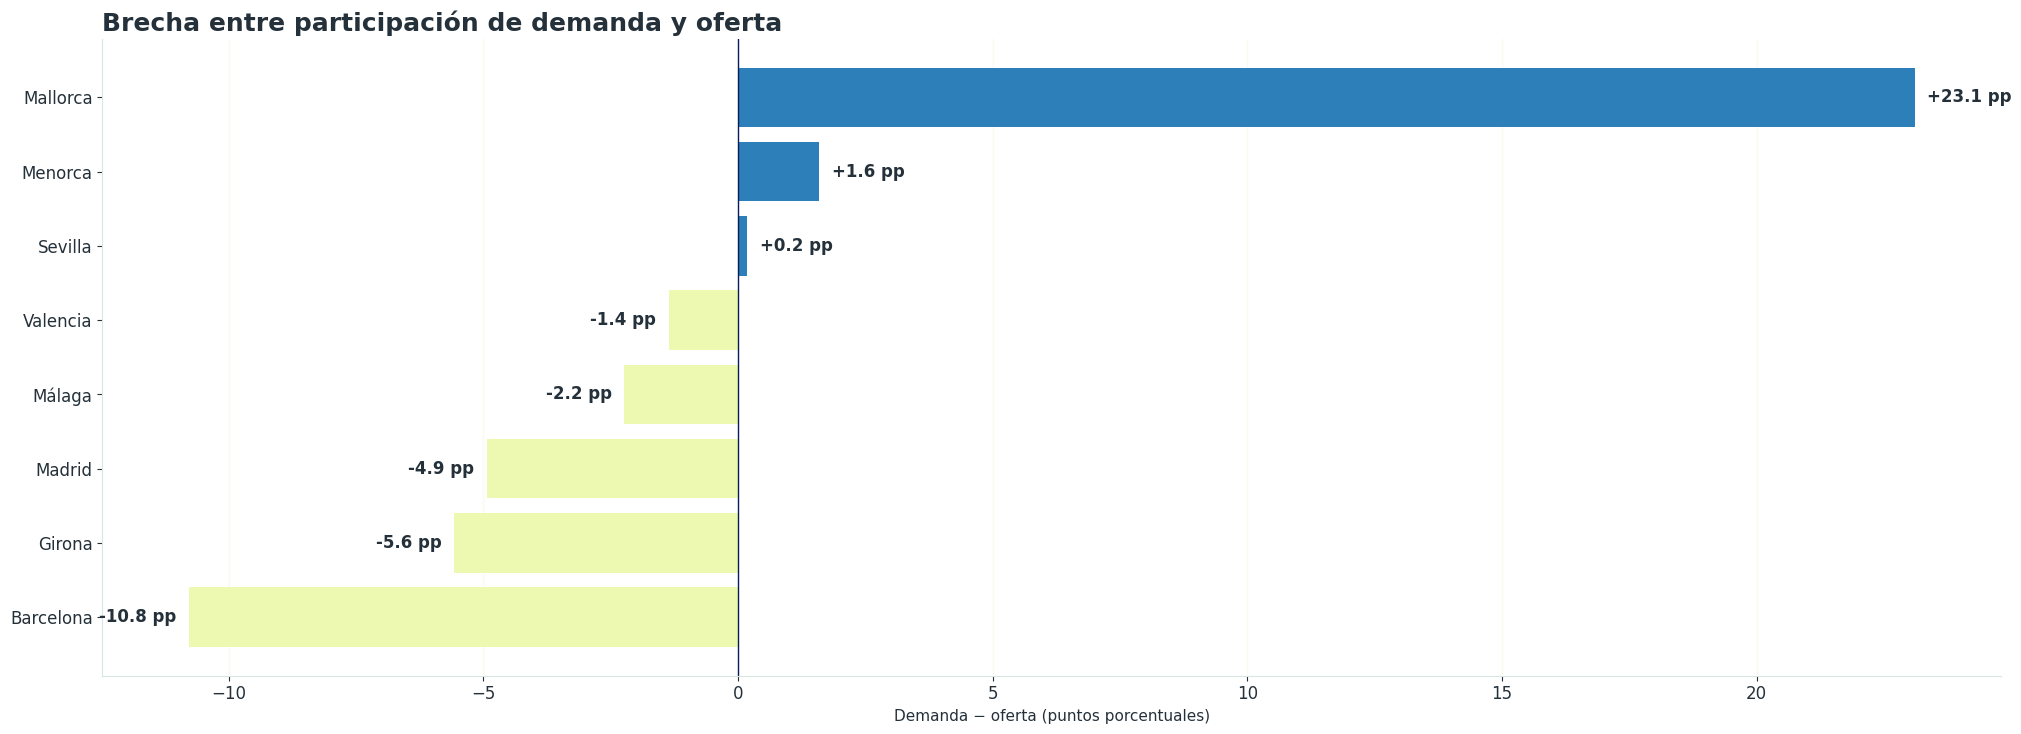

In [24]:
datos = tabla_maestra.sort_values("demand_minus_supply_gap_pp").copy()
colores = [STATUS_POSITIVE if x >= 0 else STATUS_NEGATIVE for x in datos["demand_minus_supply_gap_pp"]]
fig, ax = plt.subplots(figsize=(20.5, 7.5))
barras = ax.barh(datos["destination"], datos["demand_minus_supply_gap_pp"], color=colores)
ax.axvline(0, color=CHART_DARK, linewidth=1)
for barra, valor in zip(barras, datos["demand_minus_supply_gap_pp"]):
    desplazamiento = 0.25 if valor >= 0 else -0.25
    ax.text(valor + desplazamiento, barra.get_y() + barra.get_height()/2, f"{valor:+.1f} pp", va="center", ha="left" if valor >= 0 else "right", fontweight="bold")
ax.set_title("Brecha entre participación de demanda y oferta", loc="left")
ax.set_xlabel("Demanda − oferta (puntos porcentuales)")
ax.set_ylabel("")
limpiar_ejes(ax, "x")
fig.tight_layout()
guardar_figura(fig, "07_brecha_demanda_menos_oferta")


<a id="interpretacion-brecha"></a>
### 🔖 Interpretación — brecha demanda menos oferta

La brecha más positiva corresponde a Mallorca (**+23,1 pp**), lo que indica que su peso en la demanda supera ampliamente su peso en la oferta. Menorca (**+1,6 pp**) y Sevilla (**+0,2 pp**) están cerca del equilibrio.

Los valores más negativos aparecen en Barcelona (**−10,8 pp**), Girona (**−5,6 pp**) y Madrid (**−4,9 pp**), donde la oferta tiene mayor peso relativo.

**Uso de negocio:** priorizar Mallorca para validación de captación; en Barcelona, Madrid y Girona, priorizar optimización y activación antes de ampliar la oferta.

[↑ Volver al índice](#indice-graficos-matrices)

<a id="grafico-procedencia"></a>
### 11.12 Principal comunidad autónoma de procedencia

[↑ Volver al índice](#indice-graficos-matrices)

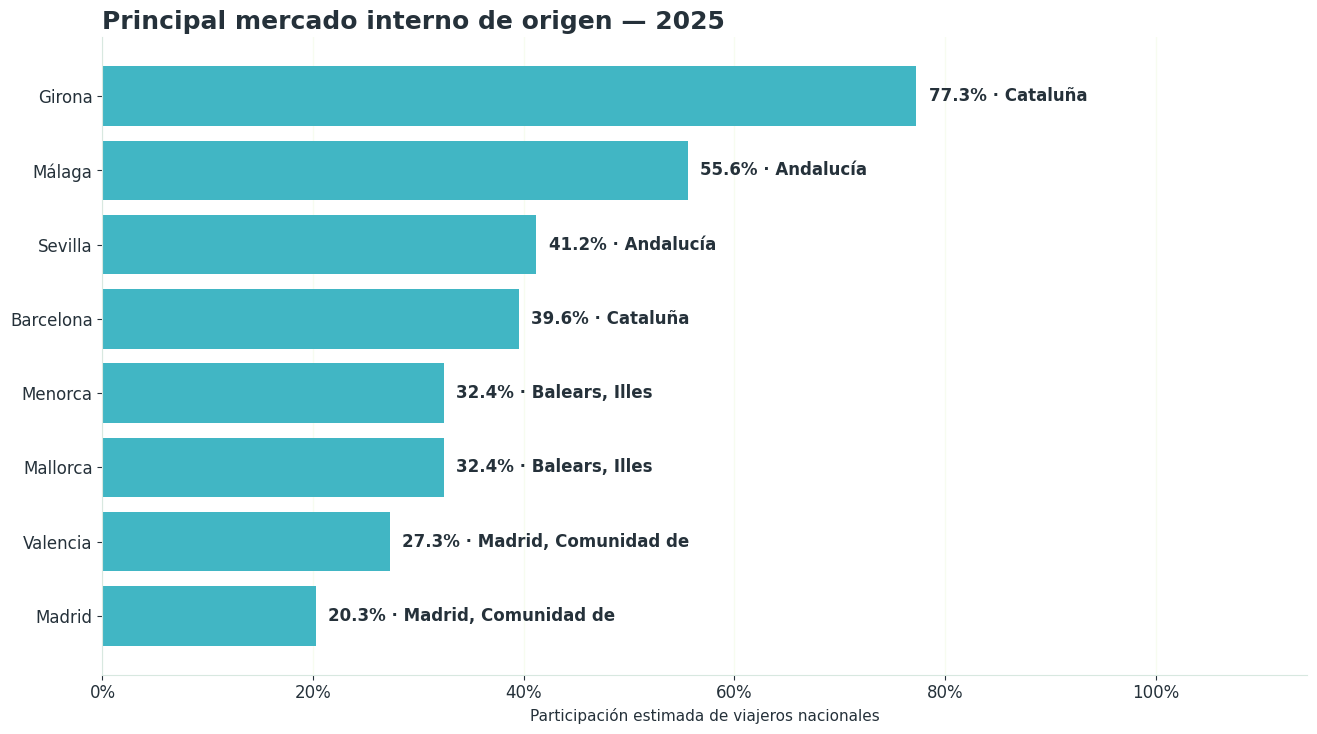

In [25]:
datos = tabla_maestra.dropna(subset=["top_origin_share_pct"]).sort_values("top_origin_share_pct").copy()
fig, ax = plt.subplots(figsize=(13.33, 7.5))
barras = ax.barh(datos["destination"], datos["top_origin_share_pct"], color=CHART_TEAL)
maximo = datos["top_origin_share_pct"].max()
for barra, (_, fila) in zip(barras, datos.iterrows()):
    etiqueta = f"{fila['top_origin_share_pct']:.1f}% · {fila['top_origin_ccaa']}"
    ax.text(fila["top_origin_share_pct"] + maximo*0.015, barra.get_y()+barra.get_height()/2, etiqueta, va="center", fontweight="bold")
ax.set_title("Principal mercado interno de origen — 2025", loc="left")
ax.set_xlabel("Participación estimada de viajeros nacionales")
ax.set_ylabel("")
ax.xaxis.set_major_formatter(mticker.PercentFormatter())
ax.set_xlim(0, maximo*1.48)
limpiar_ejes(ax, "x")
fig.tight_layout()
guardar_figura(fig, "08_principal_origen_ccaa_2025")


<a id="interpretacion-procedencia"></a>
### 🔖 Interpretación — principal CCAA de procedencia nacional

La procedencia interna está muy concentrada en algunos mercados:

- Girona: Cataluña representa **77,3%** del origen nacional estimado.
- Málaga: Andalucía, **55,6%**.
- Sevilla: Andalucía, **41,2%**.
- Barcelona: Cataluña, **39,6%**.
- Valencia: Comunidad de Madrid, **27,3%**.
- Madrid: Comunidad de Madrid, **20,3%**, con un origen más diversificado.

Mallorca y Menorca comparten el dato provincial de Illes Balears (**32,4%**); no debe interpretarse como un resultado específico de cada isla.

**Implicación:** las campañas nacionales pueden personalizarse por CCAA, especialmente en Girona, Málaga y Sevilla.

[↑ Volver al índice](#indice-graficos-matrices)

<a id="grafico-crecimiento"></a>
### 11.13 Crecimiento de las pernoctaciones 2023–2025

[↑ Volver al índice](#indice-graficos-matrices)

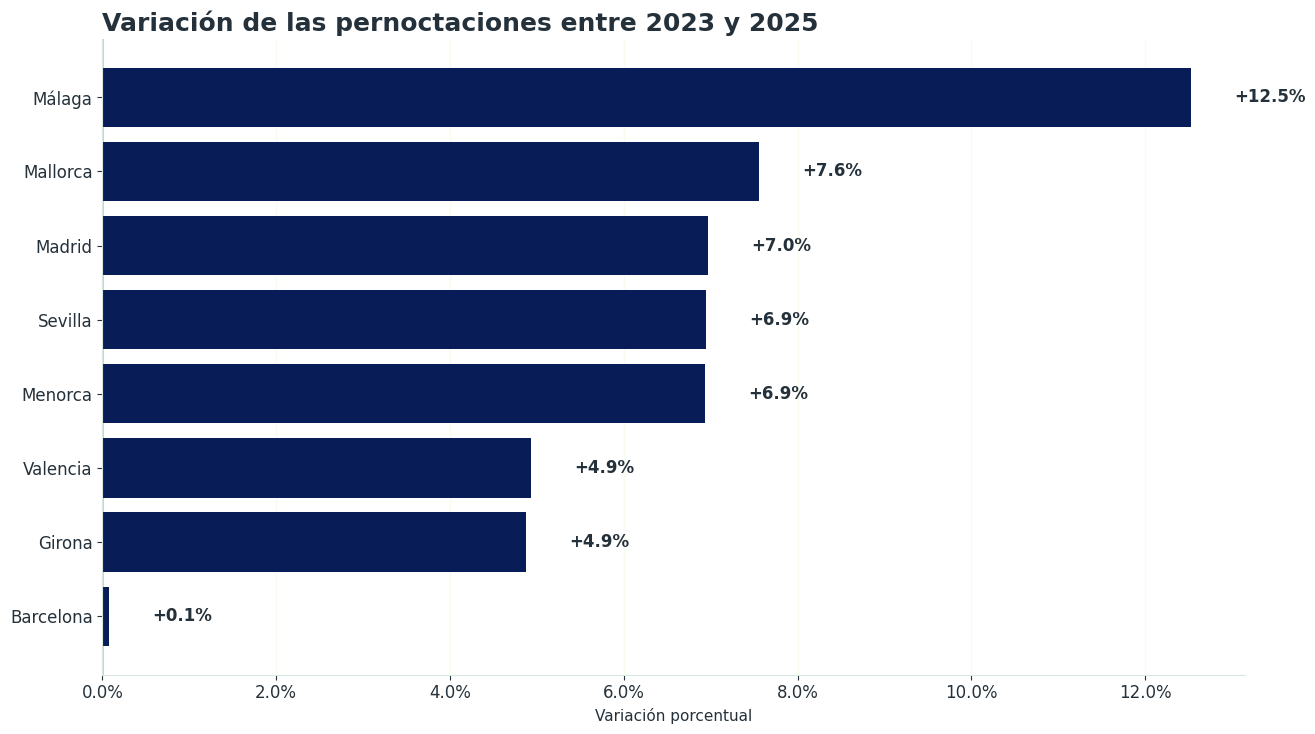

In [26]:
datos = tabla_maestra.dropna(subset=["growth_2023_2025_pct"]).sort_values("growth_2023_2025_pct").copy()
colores = [STATUS_NEGATIVE if x < 0 else STATUS_STRATEGIC for x in datos["growth_2023_2025_pct"]]
fig, ax = plt.subplots(figsize=(13.33, 7.5))
barras = ax.barh(datos["destination"], datos["growth_2023_2025_pct"], color=colores)
ax.axvline(0, color=CHART_DARK, linewidth=1)
for barra, valor in zip(barras, datos["growth_2023_2025_pct"]):
    ax.text(valor + (0.5 if valor >= 0 else -0.5), barra.get_y()+barra.get_height()/2, f"{valor:+.1f}%", va="center", ha="left" if valor >= 0 else "right", fontweight="bold")
ax.set_title("Variación de las pernoctaciones entre 2023 y 2025", loc="left")
ax.set_xlabel("Variación porcentual")
ax.set_ylabel("")
ax.xaxis.set_major_formatter(mticker.PercentFormatter())
limpiar_ejes(ax, "x")
fig.tight_layout()
guardar_figura(fig, "09_crecimiento_pernoctaciones_2023_2025")


<a id="interpretacion-crecimiento"></a>
### 🔖 Interpretación — crecimiento de pernoctaciones 2023–2025

Todos los destinos registran variación positiva entre 2023 y 2025:

- Málaga: **+12,5%**, el mayor crecimiento.
- Mallorca: **+7,6%**.
- Madrid, Menorca y Sevilla: alrededor de **+6,9%**.
- Girona y Valencia: aproximadamente **+4,9%**.
- Barcelona: **+0,1%**, prácticamente estable.

**Conclusión:** Málaga es el mercado con mayor dinamismo reciente, mientras que Barcelona mantiene gran escala pero sin crecimiento relevante en el periodo.

> La variación histórica no constituye una previsión de demanda futura.

[↑ Volver al índice](#indice-graficos-matrices)

<a id="tabla-opportunity-matrix"></a>
## 12. Opportunity Matrix y tabla resumen de presentación

[↑ Volver al índice](#indice-graficos-matrices)

In [27]:
columnas_opportunity = [
    "priority_rank_gap","destination","strategic_quadrant","demand_share_pct","supply_share_pct","demand_minus_supply_gap_pp","total_overnight_stays",
    "average_stay_total","growth_2023_2025_pct","international_share_pct","top_origin_ccaa","top_origin_share_pct","peak_month_total","low_month_total",
    "seasonal_concentration_pct","unique_listings","median_price_eur","median_minimum_nights","median_rating","review_coverage_pct","recommended_action",
]

opportunity_matrix = tabla_maestra[
    [c for c in columnas_opportunity if c in tabla_maestra.columns]
].copy()


columnas_slide = [
    "destination","strategic_quadrant","demand_minus_supply_gap_pp","international_share_pct","top_origin_ccaa","peak_month_total",
    "average_stay_total","unique_listings","median_price_eur","median_minimum_nights","recommended_action",
]

tabla_resumen_presentacion = tabla_maestra[
    [c for c in columnas_slide if c in tabla_maestra.columns]
].copy()


# Nombres en castellano solo para la visualización
nombres_columnas_es = {
    "priority_rank_gap": "Orden por brecha D−O","destination": "Destino","strategic_quadrant": "Cuadrante estratégico",
    "demand_share_pct": "Participación de la demanda (%)","supply_share_pct": "Participación de la oferta (%)",
    "demand_minus_supply_gap_pp": "Brecha demanda − oferta (pp)","total_overnight_stays": "Pernoctaciones totales",
    "average_stay_total": "Estancia media (noches)","growth_2023_2025_pct": "Crecimiento 2023–2025 (%)",
    "international_share_pct": "Pernoctaciones internacionales (%)","top_origin_ccaa": "Principal CCAA de origen",
    "top_origin_share_pct": "Peso del principal origen (%)","peak_month_total": "Mes de mayor demanda",
    "low_month_total": "Mes de menor demanda","seasonal_concentration_pct": "Concentración en los 3 meses principales (%)",
    "unique_listings": "Alojamientos únicos","median_price_eur": "Precio mediano (€)",
    "median_minimum_nights": "Noches mínimas medianas","median_rating": "Valoración mediana",
    "review_coverage_pct": "Cobertura de reseñas (%)","recommended_action":"Acción recomendada",
}


opportunity_matrix_es = opportunity_matrix.rename(
    columns=nombres_columnas_es
)

tabla_resumen_presentacion_es = tabla_resumen_presentacion.rename(
    columns=nombres_columnas_es
)


display(Markdown("### Matriz de oportunidad"))
display(opportunity_matrix_es.round(2))

display(Markdown(
    '<a id="tabla-resumen-presentacion"></a>\n'
    '### Tabla corta para la diapositiva'
))
display(tabla_resumen_presentacion_es.round(2))

### Matriz de oportunidad

,Orden por brecha D−O,Destino,Cuadrante estratégico,Participación de la demanda (%),Participación de la oferta (%),Brecha demanda − oferta (pp),Pernoctaciones totales,Estancia media (noches),Crecimiento 2023–2025 (%),Pernoctaciones internacionales (%),Principal CCAA de origen,Peso del principal origen (%),Mes de mayor demanda,Mes de menor demanda,Concentración en los 3 meses principales (%),Alojamientos únicos,Precio mediano (€),Noches mínimas medianas,Valoración mediana,Cobertura de reseñas (%),Acción recomendada
0,1,Mallorca,Mercado estratégico,39.51,16.40,23.11,"49,265,920.00",5.27,7.55,93.70,"Balears, Illes",32.43,Agosto,Enero,48.88,1583,"1,360.00",4.00,96.00,61.34,Priorizar captación selectiva y campañas internacionales; reforzar la temporada baja.
1,2,Menorca,Monitorizar,3.85,2.26,1.59,"4,798,290.00",5.72,6.94,82.59,"Balears, Illes",32.43,Agosto,Febrero,59.69,218,"1,380.00",4.00,95.00,66.97,Captación selectiva y producto vacacional; validar la capacidad fuera de temporada.
2,3,Sevilla,Monitorizar,5.30,5.12,0.18,"6,612,695.00",2.12,6.94,69.61,Andalucía,41.19,Mayo,Enero,28.27,494,690.00,2.00,95.00,86.44,Mantener balance; activar campañas en meses valle y mercados de origen prioritarios.
3,4,Valencia,Monitorizar,3.95,5.32,-1.36,"4,929,683.00",2.31,4.93,65.90,"Madrid, Comunidad de",27.31,Agosto,Enero,29.48,513,575.00,2.00,94.00,83.43,Optimizar pricing y campañas por origen; vigilar el desajuste moderado.
4,5,Málaga,Monitorizar,2.99,5.22,-2.23,"3,730,780.00",2.04,12.53,69.16,Andalucía,55.61,Agosto,Enero,30.08,504,600.00,2.00,94.00,82.34,Combinar campañas urbanas y estacionales; aprovechar el crecimiento reciente y validar la respuesta de la oferta disponible.
5,6,Madrid,Mercado estratégico,17.18,22.11,-4.93,"21,422,510.00",2.06,6.97,65.97,"Madrid, Comunidad de",20.25,Octubre,Febrero,27.55,2134,600.00,2.00,95.00,77.09,Priorizar conversión y estancias cortas; no ampliar oferta de forma general.
6,7,Girona,Mercado estratégico,9.82,15.39,-5.57,"12,246,036.00",3.01,4.87,71.81,Cataluña,77.27,Agosto,Enero,49.10,1485,940.00,2.00,94.00,61.14,Mejorar utilización con campañas estacionales; revisar la distribución de noches mínimas.
7,8,Barcelona,Mercado estratégico,17.39,28.18,-10.78,"21,686,712.00",2.41,0.07,87.68,Cataluña,39.56,Agosto,Enero,28.79,2719,600.00,2.00,93.00,76.68,Optimizar conversión y segmentar oferta; tratar como mercado diferenciado.


<a id="tabla-resumen-presentacion"></a>
### Tabla corta para la diapositiva

,Destino,Cuadrante estratégico,Brecha demanda − oferta (pp),Pernoctaciones internacionales (%),Principal CCAA de origen,Mes de mayor demanda,Estancia media (noches),Alojamientos únicos,Precio mediano (€),Noches mínimas medianas,Acción recomendada
0,Mallorca,Mercado estratégico,23.11,93.70,"Balears, Illes",Agosto,5.27,1583,"1,360.00",4.00,Priorizar captación selectiva y campañas internacionales; reforzar la temporada baja.
1,Menorca,Monitorizar,1.59,82.59,"Balears, Illes",Agosto,5.72,218,"1,380.00",4.00,Captación selectiva y producto vacacional; validar la capacidad fuera de temporada.
2,Sevilla,Monitorizar,0.18,69.61,Andalucía,Mayo,2.12,494,690.00,2.00,Mantener balance; activar campañas en meses valle y mercados de origen prioritarios.
3,Valencia,Monitorizar,-1.36,65.90,"Madrid, Comunidad de",Agosto,2.31,513,575.00,2.00,Optimizar pricing y campañas por origen; vigilar el desajuste moderado.
4,Málaga,Monitorizar,-2.23,69.16,Andalucía,Agosto,2.04,504,600.00,2.00,Combinar campañas urbanas y estacionales; aprovechar el crecimiento reciente y validar la respuesta de la oferta disponible.
5,Madrid,Mercado estratégico,-4.93,65.97,"Madrid, Comunidad de",Octubre,2.06,2134,600.00,2.00,Priorizar conversión y estancias cortas; no ampliar oferta de forma general.
6,Girona,Mercado estratégico,-5.57,71.81,Cataluña,Agosto,3.01,1485,940.00,2.00,Mejorar utilización con campañas estacionales; revisar la distribución de noches mínimas.
7,Barcelona,Mercado estratégico,-10.78,87.68,Cataluña,Agosto,2.41,2719,600.00,2.00,Optimizar conversión y segmentar oferta; tratar como mercado diferenciado.


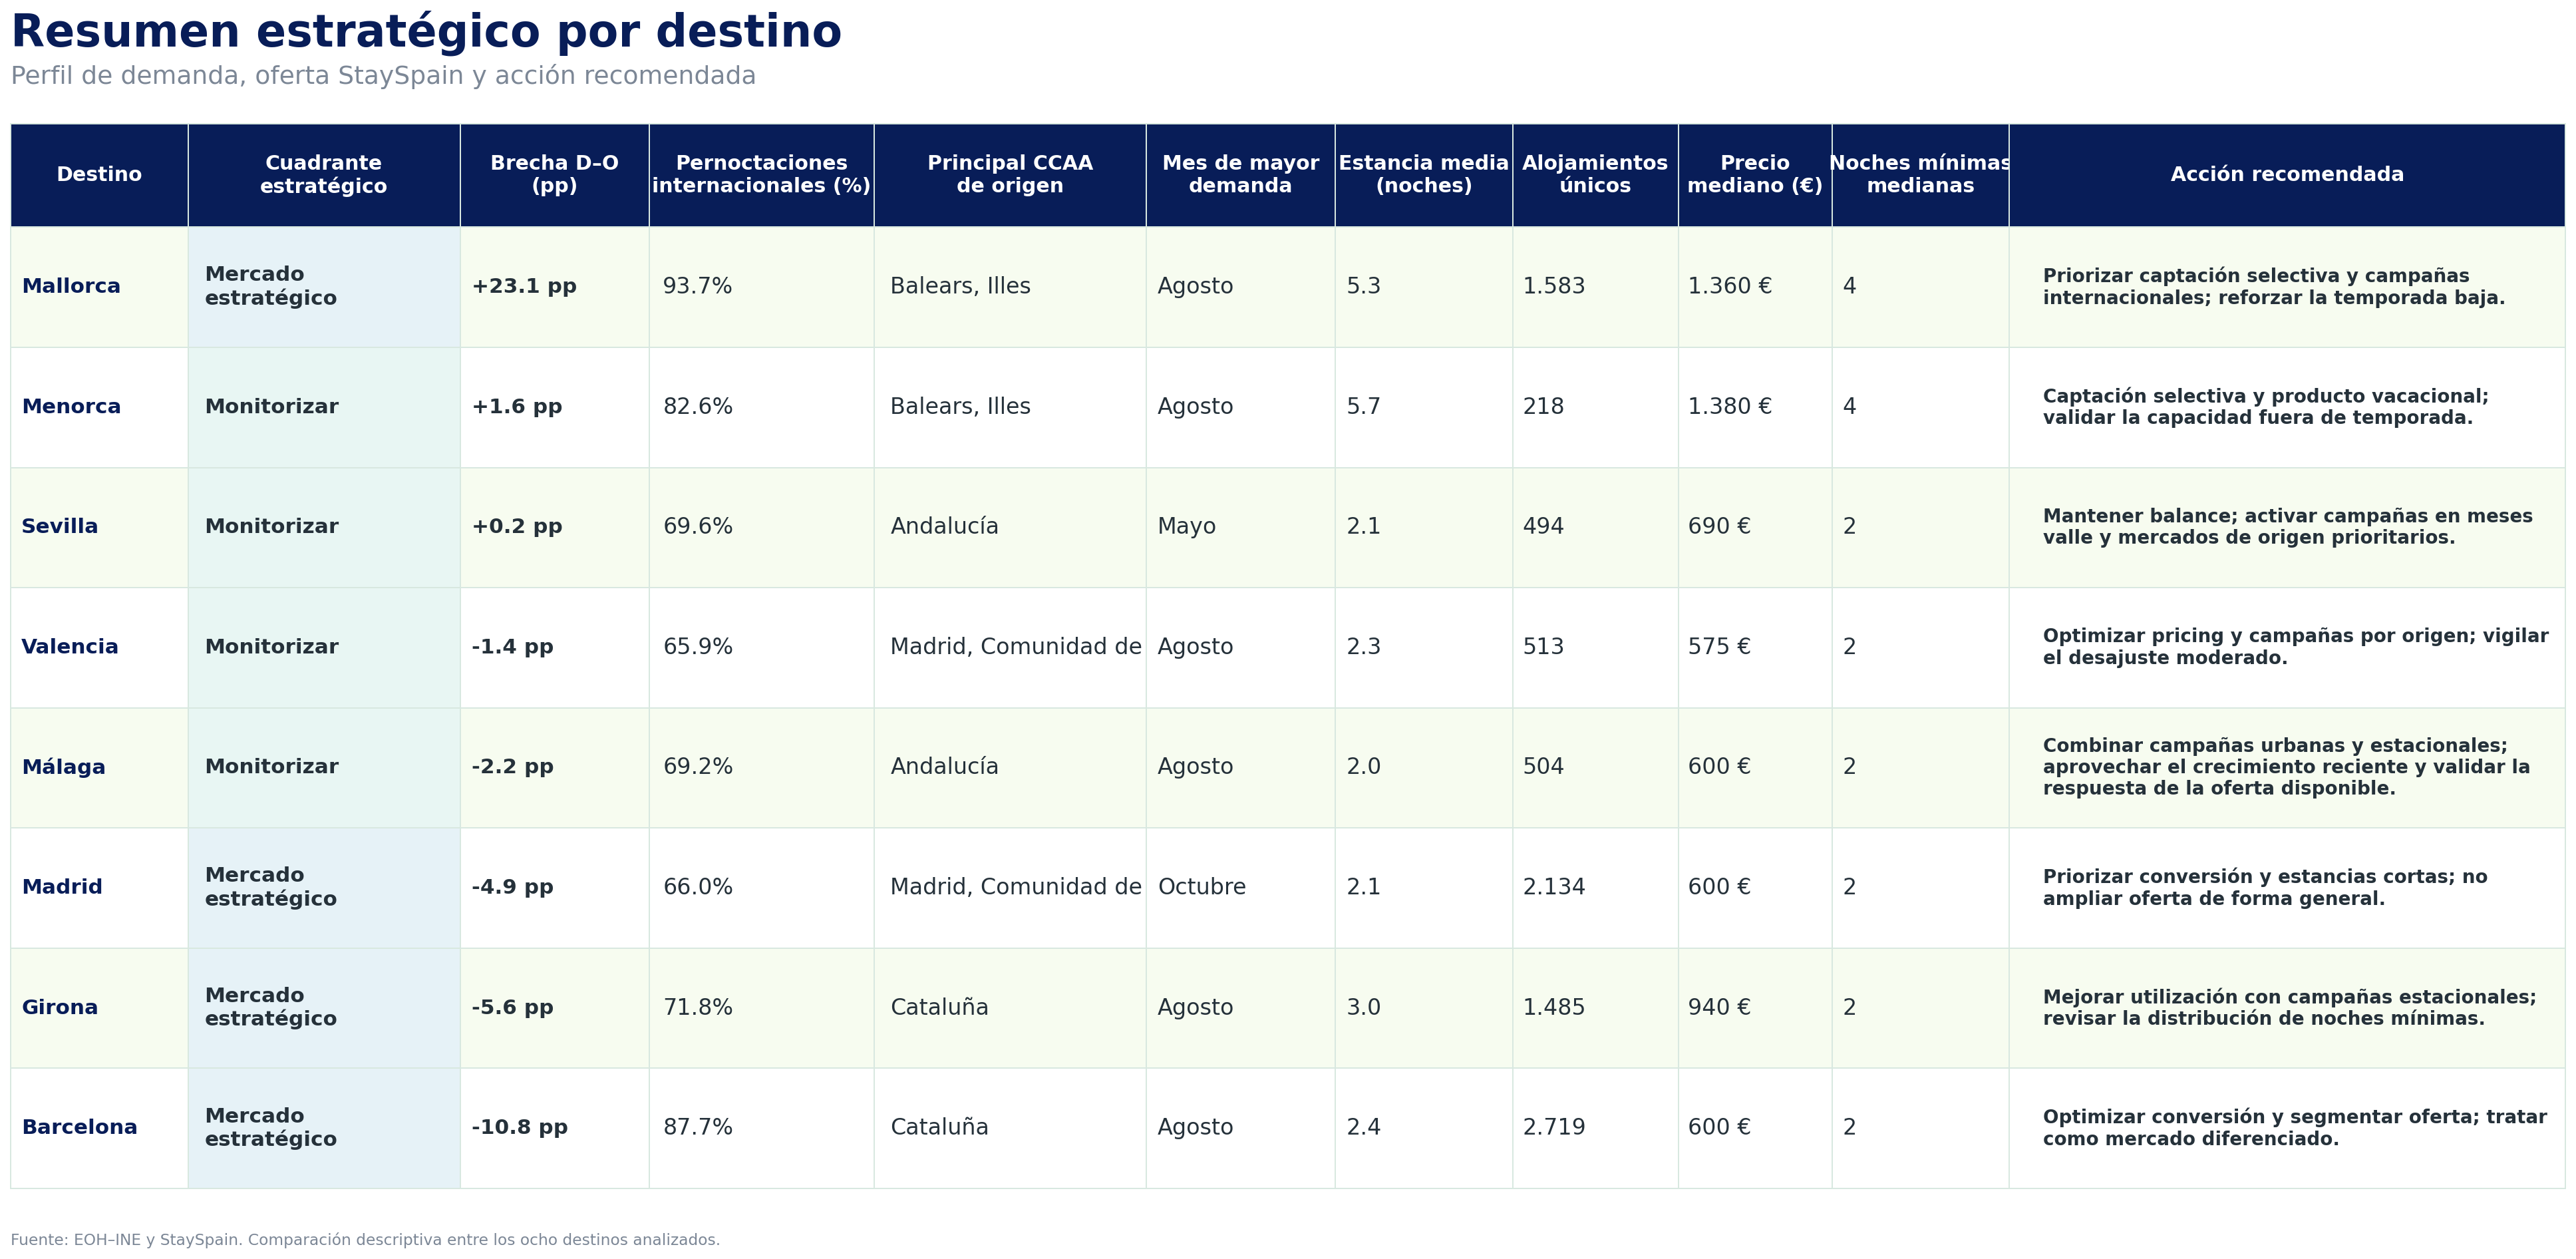

In [28]:
def crear_tabla_resumen_grafica():

    # ----------------------------------------------------
    # 1. Preparar la tabla
    # ----------------------------------------------------
    if "tabla_resumen_presentacion_es" in globals():
        tabla = tabla_resumen_presentacion_es.copy()
    else:
        tabla = tabla_resumen_presentacion.rename(columns=nombres_columnas_es).copy()

    columnas = ["Destino","Cuadrante estratégico","Brecha demanda − oferta (pp)","Pernoctaciones internacionales (%)",
        "Principal CCAA de origen","Mes de mayor demanda","Estancia media (noches)","Alojamientos únicos",
        "Precio mediano (€)","Noches mínimas medianas","Acción recomendada",
    ]

    tabla = tabla[[col for col in columnas if col in tabla.columns]].copy()
    # ----------------------------------------------------
    # 2. Formato de valores
    # ----------------------------------------------------
    tabla["Brecha demanda − oferta (pp)"] = tabla["Brecha demanda − oferta (pp)"
    ].map(
        lambda x: f"{x:+.1f} pp"
        if pd.notna(x)
        else "N/D"
    )

    tabla["Pernoctaciones internacionales (%)"] = tabla["Pernoctaciones internacionales (%)"
    ].map(
        lambda x: f"{x:.1f}%"
        if pd.notna(x)
        else "N/D"
    )

    tabla["Estancia media (noches)"] = tabla["Estancia media (noches)"
    ].map(
        lambda x: f"{x:.1f}"
        if pd.notna(x)
        else "N/D"
    )

    tabla["Alojamientos únicos"] = tabla["Alojamientos únicos"
    ].map(
        lambda x: f"{int(x):,}".replace(",", ".")
        if pd.notna(x)
        else "N/D"
    )

    tabla["Precio mediano (€)"] = tabla["Precio mediano (€)"
    ].map(
        lambda x: f"{x:,.0f} €".replace(",", ".")
        if pd.notna(x)
        else "N/D"
    )

    tabla["Noches mínimas medianas"] = tabla["Noches mínimas medianas"
    ].map(
        lambda x: f"{x:.0f}"
        if pd.notna(x)
        else "N/D"
    )

    # ----------------------------------------------------
    # 3. Ajustar textos largos
    # ----------------------------------------------------
    tabla["Cuadrante estratégico"] = tabla["Cuadrante estratégico"
    ].fillna("N/D").map(
        lambda texto: textwrap.fill(str(texto), 18)
    )

    tabla["Principal CCAA de origen"] = tabla["Principal CCAA de origen"
    ].fillna("N/D").map(
        lambda texto: textwrap.fill(str(texto), 22)
    )

    tabla["Acción recomendada"] = tabla["Acción recomendada"
    ].fillna("N/D").map(
        lambda texto: textwrap.fill(str(texto), 48)
    )

    # ----------------------------------------------------
    # 4. Nombres cortos para los encabezados
    # ----------------------------------------------------
    nombres_cortos = {"Destino": "Destino","Cuadrante estratégico": "Cuadrante\nestratégico",
        "Brecha demanda − oferta (pp)": "Brecha D–O\n(pp)",
        "Pernoctaciones internacionales (%)":"Pernoctaciones\ninternacionales (%)",
        "Principal CCAA de origen":"Principal CCAA\nde origen","Mes de mayor demanda":"Mes de mayor\ndemanda",
        "Estancia media (noches)":"Estancia media\n(noches)","Alojamientos únicos":"Alojamientos\núnicos",
        "Precio mediano (€)":"Precio\nmediano (€)","Noches mínimas medianas":"Noches mínimas\nmedianas",
        "Acción recomendada":"Acción recomendada",
    }

    tabla_visual = tabla.rename(
        columns=nombres_cortos
    )

    # ----------------------------------------------------
    # 5. Crear figura
    # ----------------------------------------------------
    fig = plt.figure(figsize=(25, 12.5),dpi=160,facecolor=WHITE,)

    ax = fig.add_axes([0.02, 0.07, 0.96, 0.80])
    ax.axis("off")

    fig.text(0.02,0.955,"Resumen estratégico por destino",fontsize=30,fontweight="bold",color=NAVY,ha="left",va="top",)

    fig.text(0.02,0.915,"Perfil de demanda, oferta StaySpain y acción recomendada",fontsize=17,fontweight="medium",color=GREY,ha="left",va="top",)

    # Más espacio para cuadrante, CCAA y acción
    anchos_columnas = [
        0.075,  # Destino
        0.115,  # Cuadrante
        0.080,  # Brecha
        0.095,  # Internacional
        0.115,  # CCAA
        0.080,  # Mes
        0.075,  # Estancia
        0.070,  # Alojamientos
        0.065,  # Precio
        0.075,  # Noches mínimas
        0.235,  # Acción
    ]

    tabla_plot = ax.table(cellText=tabla_visual.values,colLabels=tabla_visual.columns,cellLoc="left",colLoc="center",colWidths=anchos_columnas,bbox=[0, 0, 1, 1],)

    tabla_plot.auto_set_font_size(False)

    # ----------------------------------------------------
    # 6. Estilo de encabezados y filas
    # ----------------------------------------------------
    for (fila, columna), celda in tabla_plot.get_celld().items():

        celda.set_edgecolor(BORDER)
        celda.set_linewidth(0.9)
        celda.PAD = 0.060

        if fila == 0:
            celda.set_facecolor(NAVY)
            celda.set_height(0.105)

            celda.set_text_props(color=WHITE,fontsize=13.5,fontweight="bold",ha="center",va="center",)

        else:
            celda.set_height(0.122)

            celda.set_facecolor(
                LIGHT_GREY if fila % 2 == 1 else WHITE
            )

            celda.set_text_props(color=DARK,fontsize=15,fontweight="normal",ha="left",va="center",)

    # ----------------------------------------------------
    # 7. Columnas destacadas
    # ----------------------------------------------------
    columnas_tabla = list(tabla_visual.columns)

    columna_destino = columnas_tabla.index("Destino")
    columna_brecha = columnas_tabla.index("Brecha D–O\n(pp)")
    columna_accion = columnas_tabla.index("Acción recomendada")
    columna_cuadrante = columnas_tabla.index("Cuadrante\nestratégico")

    for fila in range(1, len(tabla_visual) + 1):

        # Destino
        tabla_plot[
            (fila, columna_destino)
        ].set_text_props(fontsize=14,fontweight="bold",color=NAVY,)

        # Brecha
        tabla_plot[
            (fila, columna_brecha)
        ].set_text_props(fontsize=14,fontweight="bold",color=DARK,
        )

        # Acción
        tabla_plot[
            (fila, columna_accion)
        ].set_text_props(fontsize=12.5,fontweight="bold",color=DARK,)

    # ----------------------------------------------------
    # 8. Colores de los cuadrantes
    # ----------------------------------------------------
    colores_cuadrante = {
        "Prioridad de expansión": PALE_YELLOW,"Mercado estratégico": PALE_BLUE,
        "Optimizar oferta": PALETTE["pale_green"],"Monitorizar": PALE_TEAL,
    }

    for fila, valor in enumerate(
        tabla["Cuadrante estratégico"],
        start=1,
    ):
        texto_cuadrante = str(valor).replace("\n", " ")

        for nombre, color in colores_cuadrante.items():
            if nombre in texto_cuadrante:

                tabla_plot[
                    (fila, columna_cuadrante)
                ].set_facecolor(color)

                tabla_plot[
                    (fila, columna_cuadrante)
                ].set_text_props(fontsize=14,fontweight="bold",color=DARK,)
                break

    # ----------------------------------------------------
    # 9. Fuente
    # ----------------------------------------------------
    fig.text(0.02,0.025,
        ("Fuente: EOH–INE y StaySpain. ""Comparación descriptiva entre los ocho destinos analizados."),
        fontsize=10.5,color=GREY,ha="left",va="bottom",)

    guardar_figura(fig,"tabla_resumen_estrategico_grafica",)


crear_tabla_resumen_grafica()

<a id="interpretacion-tabla-opportunity"></a>

### 15. 🔖 Interpretación — resumen estratégico por destino

La tabla está ordenada por la brecha entre la participación de la demanda EOH y la participación de la oferta StaySpain. Este orden no representa por sí solo una prioridad definitiva de inversión.

Mallorca ocupa la primera posición por su brecha positiva de **+23,1 pp**. Barcelona aparece en el extremo contrario con **−10,8 pp**, aunque continúa siendo un mercado estratégico por su gran escala de demanda.

La decisión final debe combinar:

- brecha demanda − oferta;
- volumen total de pernoctaciones;
- crecimiento reciente;
- estacionalidad;
- estancia media;
- perfil internacional;
- características y calidad de la oferta StaySpain.

**Implicación:** Mallorca requiere captación selectiva y campañas internacionales, además de acciones para reforzar la temporada baja. Barcelona, Madrid y Girona necesitan principalmente optimización y activación de la oferta existente. Málaga merece seguimiento por su crecimiento reciente y su perfil híbrido urbano-costero.

> Las recomendaciones son provisionales. Antes de utilizar el precio en decisiones, debe confirmarse la unidad temporal del campo `price`.

[↑ Volver al índice](#indice-graficos-matrices)s)

<a id="salidas-inline"></a>
## 13. Salidas dentro del notebook

Las tablas siguientes se muestran para revisión, presentación y copia manual.  
No se guarda ningún archivo fuera del notebook.


In [29]:
mostrar_tabla(tabla_maestra, "Tabla maestra oferta–demanda")
mostrar_tabla(opportunity_matrix_es,"Opportunity Matrix por destino")
mostrar_tabla(tabla_resumen_presentacion_es,"Tabla corta para diapositiva")
mostrar_tabla(validaciones, "Controles de validación")

display(Markdown(
    "✅ **Modo inline confirmado:** todos los gráficos y tablas permanecen "
    "dentro del notebook; no se han creado archivos externos."
))

#### Tabla maestra oferta–demanda

,destination,national_travelers,international_travelers,national_overnight_stays,international_overnight_stays,total_travelers,total_overnight_stays,average_stay_total,average_stay_national,average_stay_international,national_share_pct,international_share_pct,peak_month_total,low_month_total,peak_month_national,peak_month_international,seasonal_concentration_pct,peak_to_low_ratio,pattern_stable_2023_2025,growth_2023_2025_pct,top_origin_ccaa,top_origin_share_pct,top3_origin_share_pct,unique_listings,dominant_room_type,median_accommodates,median_price_eur,median_minimum_nights,median_availability_365,median_occupancy_pct,median_rating,review_coverage_pct,demand_share_pct,supply_share_pct,demand_minus_supply_gap_pp,supply_vs_demand_gap_pp,demand_per_listing,minimum_vs_average_stay_nights,strategic_quadrant,recommended_action_provisional,priority_rank_gap,identified_mismatch,recommended_action,market_group
0,Mallorca,887856.000000,8460662.000000,3102889.000000,46163031.000000,9348518.000000,49265920.000000,5.270000,3.490000,5.460000,6.300000,93.700000,Agosto,Enero,Agosto,Agosto,48.880000,39.590000,Sí,7.550000,"Balears, Illes",32.430000,63.980000,1583,Entire home/apt,6.000000,1360.000000,4.000000,220.000000,56.670000,96.000000,61.340000,39.510000,16.400000,23.110000,-23.110000,31121.870000,-1.270000,Mercado estratégico,Defender calidad y afinar campañas por origen y temporada.,1,Oferta relativa baja (-23.1 pp),Priorizar captación selectiva y campañas internacionales; reforzar la temporada baja.,Vacacional insular internacional
1,Menorca,205840.000000,633138.000000,835401.000000,3962889.000000,838978.000000,4798290.000000,5.720000,4.060000,6.260000,17.410000,82.590000,Agosto,Febrero,Agosto,Agosto,59.690000,169.770000,Sí,6.940000,"Balears, Illes",32.430000,63.980000,218,Entire home/apt,6.000000,1380.000000,4.000000,180.000000,50.000000,95.000000,66.970000,3.850000,2.260000,1.590000,-1.590000,22010.500000,-1.720000,Monitorizar,Mantener seguimiento y validar demanda antes de invertir más.,2,Oferta alineada (-1.6 pp),Captación selectiva y producto vacacional; validar la capacidad fuera de temporada.,Vacacional insular internacional
2,Sevilla,1169515.000000,1956154.000000,2009362.000000,4603333.000000,3125669.000000,6612695.000000,2.120000,1.720000,2.350000,30.390000,69.610000,Mayo,Enero,Diciembre,Octubre,28.270000,1.390000,No,6.940000,Andalucía,41.190000,68.810000,494,Entire home/apt,4.000000,690.000000,2.000000,198.500000,50.000000,95.000000,86.440000,5.300000,5.120000,0.180000,-0.180000,13386.020000,-0.120000,Monitorizar,Mantener seguimiento y validar demanda antes de invertir más.,3,Oferta alineada (-0.2 pp),Mantener balance; activar campañas en meses valle y mercados de origen prioritarios.,Urbano mixto de estancia corta
3,Valencia,935103.000000,1197208.000000,1680890.000000,3248793.000000,2132311.000000,4929683.000000,2.310000,1.800000,2.710000,34.100000,65.900000,Agosto,Enero,Noviembre,Agosto,29.480000,1.780000,Sí,4.930000,"Madrid, Comunidad de",27.310000,63.980000,513,Entire home/apt,4.000000,575.000000,2.000000,159.000000,63.330000,94.000000,83.430000,3.950000,5.320000,-1.360000,1.360000,9609.520000,-0.310000,Monitorizar,Mantener seguimiento y validar demanda antes de invertir más.,4,Oferta alineada (+1.4 pp),Optimizar pricing y campañas por origen; vigilar el desajuste moderado.,Urbano mixto de estancia corta
4,Málaga,657316.000000,1175237.000000,1150737.000000,2580043.000000,1832553.000000,3730780.000000,2.040000,1.750000,2.200000,30.840000,69.160000,Agosto,Enero,Agosto,Agosto,30.080000,1.850000,Sí,12.530000,Andalucía,55.610000,76.050000,504,Entire home/apt,4.000000,600.000000,2.000000,215.000000,63.330000,94.000000,82.340000,2.990000,5.220000,-2.230000,2.230000,7402.340000,-0.040000,Monitorizar,Mantener seguimiento y validar demanda antes de invertir más.,5,Desajuste moderado (+2.2 pp),Combinar campañas urbanas y estacionales; aprovechar el crecimiento reciente y validar la respuesta de la oferta disponible.,Híbrido urbano-co

#### Opportunity Matrix por destino

,Orden por brecha D−O,Destino,Cuadrante estratégico,Participación de la demanda (%),Participación de la oferta (%),Brecha demanda − oferta (pp),Pernoctaciones totales,Estancia media (noches),Crecimiento 2023–2025 (%),Pernoctaciones internacionales (%),Principal CCAA de origen,Peso del principal origen (%),Mes de mayor demanda,Mes de menor demanda,Concentración en los 3 meses principales (%),Alojamientos únicos,Precio mediano (€),Noches mínimas medianas,Valoración mediana,Cobertura de reseñas (%),Acción recomendada
0,1,Mallorca,Mercado estratégico,39.510000,16.400000,23.110000,49265920.000000,5.270000,7.550000,93.700000,"Balears, Illes",32.430000,Agosto,Enero,48.880000,1583,1360.000000,4.000000,96.000000,61.340000,Priorizar captación selectiva y campañas internacionales; reforzar la temporada baja.
1,2,Menorca,Monitorizar,3.850000,2.260000,1.590000,4798290.000000,5.720000,6.940000,82.590000,"Balears, Illes",32.430000,Agosto,Febrero,59.690000,218,1380.000000,4.000000,95.000000,66.970000,Captación selectiva y producto vacacional; validar la capacidad fuera de temporada.
2,3,Sevilla,Monitorizar,5.300000,5.120000,0.180000,6612695.000000,2.120000,6.940000,69.610000,Andalucía,41.190000,Mayo,Enero,28.270000,494,690.000000,2.000000,95.000000,86.440000,Mantener balance; activar campañas en meses valle y mercados de origen prioritarios.
3,4,Valencia,Monitorizar,3.950000,5.320000,-1.360000,4929683.000000,2.310000,4.930000,65.900000,"Madrid, Comunidad de",27.310000,Agosto,Enero,29.480000,513,575.000000,2.000000,94.000000,83.430000,Optimizar pricing y campañas por origen; vigilar el desajuste moderado.
4,5,Málaga,Monitorizar,2.990000,5.220000,-2.230000,3730780.000000,2.040000,12.530000,69.160000,Andalucía,55.610000,Agosto,Enero,30.080000,504,600.000000,2.000000,94.000000,82.340000,Combinar campañas urbanas y estacionales; aprovechar el crecimiento reciente y validar la respuesta de la oferta disponible.
5,6,Madrid,Mercado estratégico,17.180000,22.110000,-4.930000,21422510.000000,2.060000,6.970000,65.970000,"Madrid, Comunidad de",20.250000,Octubre,Febrero,27.550000,2134,600.000000,2.000000,95.000000,77.090000,Priorizar conversión y estancias cortas; no ampliar oferta de forma general.
6,7,Girona,Mercado estratégico,9.820000,15.390000,-5.570000,12246036.000000,3.010000,4.870000,71.810000,Cataluña,77.270000,Agosto,Enero,49.100000,1485,940.000000,2.000000,94.000000,61.140000,Mejorar utilización con campañas estacionales; revisar la distribución de noches mínimas.
7,8,Barcelona,Mercado estratégico,17.390000,28.180000,-10.780000,21686712.000000,2.410000,0.070000,87.680000,Cataluña,39.560000,Agosto,Enero,28.790000,2719,600.000000,2.000000,93.000000,76.680000,Optimizar conversión y segmentar oferta; tratar como mercado diferenciado.


#### Tabla corta para diapositiva

,Destino,Cuadrante estratégico,Brecha demanda − oferta (pp),Pernoctaciones internacionales (%),Principal CCAA de origen,Mes de mayor demanda,Estancia media (noches),Alojamientos únicos,Precio mediano (€),Noches mínimas medianas,Acción recomendada
0,Mallorca,Mercado estratégico,23.110000,93.700000,"Balears, Illes",Agosto,5.270000,1583,1360.000000,4.000000,Priorizar captación selectiva y campañas internacionales; reforzar la temporada baja.
1,Menorca,Monitorizar,1.590000,82.590000,"Balears, Illes",Agosto,5.720000,218,1380.000000,4.000000,Captación selectiva y producto vacacional; validar la capacidad fuera de temporada.
2,Sevilla,Monitorizar,0.180000,69.610000,Andalucía,Mayo,2.120000,494,690.000000,2.000000,Mantener balance; activar campañas en meses valle y mercados de origen prioritarios.
3,Valencia,Monitorizar,-1.360000,65.900000,"Madrid, Comunidad de",Agosto,2.310000,513,575.000000,2.000000,Optimizar pricing y campañas por origen; vigilar el desajuste moderado.
4,Málaga,Monitorizar,-2.230000,69.160000,Andalucía,Agosto,2.040000,504,600.000000,2.000000,Combinar campañas urbanas y estacionales; aprovechar el crecimiento reciente y validar la respuesta de la oferta disponible.
5,Madrid,Mercado estratégico,-4.930000,65.970000,"Madrid, Comunidad de",Octubre,2.060000,2134,600.000000,2.000000,Priorizar conversión y estancias cortas; no ampliar oferta de forma general.
6,Girona,Mercado estratégico,-5.570000,71.810000,Cataluña,Agosto,3.010000,1485,940.000000,2.000000,Mejorar utilización con campañas estacionales; revisar la distribución de noches mínimas.
7,Barcelona,Mercado estratégico,-10.780000,87.680000,Cataluña,Agosto,2.410000,2719,600.000000,2.000000,Optimizar conversión y segmentar oferta; tratar como mercado diferenciado.


#### Controles de validación

,control,estado,detalle
0,Cobertura — demanda EOH,OK,8 destinos
1,Cobertura — estacionalidad,OK,8 destinos
2,Cobertura — procedencia,OK,8 destinos
3,Cobertura — oferta StaySpain,OK,8 destinos
4,Nacional + internacional,OK,mín=100.00; máx=100.00
5,Participación demanda,OK,100.00%
6,Participación oferta,OK,100.00%


✅ **Modo inline confirmado:** todos los gráficos y tablas permanecen dentro del notebook; no se han creado archivos externos.

In [30]:
print(tabla_resumen_presentacion_es.round(2).to_csv(sep="\t", index=False))

Destino	Cuadrante estratégico	Brecha demanda − oferta (pp)	Pernoctaciones internacionales (%)	Principal CCAA de origen	Mes de mayor demanda	Estancia media (noches)	Alojamientos únicos	Precio mediano (€)	Noches mínimas medianas	Acción recomendada
Mallorca	Mercado estratégico	23.11	93.7	Balears, Illes	Agosto	5.27	1583	1360.0	4.0	Priorizar captación selectiva y campañas internacionales; reforzar la temporada baja.
Menorca	Monitorizar	1.59	82.59	Balears, Illes	Agosto	5.72	218	1380.0	4.0	Captación selectiva y producto vacacional; validar la capacidad fuera de temporada.
Sevilla	Monitorizar	0.18	69.61	Andalucía	Mayo	2.12	494	690.0	2.0	Mantener balance; activar campañas en meses valle y mercados de origen prioritarios.
Valencia	Monitorizar	-1.36	65.9	Madrid, Comunidad de	Agosto	2.31	513	575.0	2.0	Optimizar pricing y campañas por origen; vigilar el desajuste moderado.
Málaga	Monitorizar	-2.23	69.16	Andalucía	Agosto	2.04	504	600.0	2.0	Combinar campañas urbanas y estacionales; aprovechar el crec

## 14. Lectura estratégica y límites

### Regla de interpretación

`evidencia observada → posible desajuste → implicación de negocio → acción provisional → validación necesaria`

### Límites que deben aparecer en la presentación

1. La EOH mide establecimientos hoteleros; StaySpain representa otra tipología de alojamiento.
2. La comparación es agregada por destino y no implica causalidad.
3. Girona se aproxima mediante **Costa Brava** en la tabla 2039.
4. Mallorca y Menorca se analizan como zonas turísticas; la procedencia interna utiliza el perfil provincial de Illes Balears.
5. El año principal de mercado es 2025, mientras que el inventario StaySpain puede pertenecer a otro periodo.
6. La brecha demanda–oferta compara participaciones relativas dentro de los ocho destinos, no niveles absolutos equivalentes.

### Uso recomendado del Opportunity Matrix

- **Prioridad de expansión:** demanda relativa alta y oferta StaySpain relativa baja.
- **Mercado estratégico:** demanda y oferta altas; proteger calidad y optimizar captación.
- **Optimizar oferta:** oferta relativa alta con demanda relativa más baja.
- **Monitorizar:** demanda y oferta relativas bajas; validar antes de invertir.

## 15. Checklist de cierre

- [ ] Los seis notebooks de referencia aparecen como `OK`.
- [ ] Los ocho destinos tienen demanda y oferta.
- [ ] Nacional + internacional suma aproximadamente 100 %.
- [ ] Las participaciones de demanda y oferta suman 100 %.
- [ ] Todos los gráficos se muestran correctamente dentro del notebook.
- [ ] Las dos matrices visuales se leen correctamente en formato 16:9.
- [ ] Los bookmarks e interpretaciones aparecen debajo de cada bloque.
- [ ] No existe ninguna ruta personal visible en el código.
- [ ] No se crea ningún output externo.
- [ ] Las recomendaciones finales se revisan manualmente con el equipo.
- [ ] Las limitaciones EOH vs. StaySpain aparecen en la presentación.


## 16. Salidas principales disponibles dentro del notebook

- Opportunity Matrix de cuadrantes.
- Opportunity Matrix de evidencia por destino.
- Opportunity Matrix de decisiones y acciones.
- Participación relativa de oferta y demanda.
- Brecha demanda − oferta.
- Estancia media vs. minimum nights.
- Perfil de pernoctaciones por residencia.
- Perfil de viajeros por residencia.
- Heatmap 2025.
- Heatmap medio 2023–2025.
- Procedencia nacional.
- Crecimiento 2023–2025.
- Tablas maestras, validaciones e interpretaciones.

Todos los elementos se muestran inline y pueden capturarse o copiarse manualmente para la presentación.
